# `IMPORTED LIBRARIES`

In [1]:
import os

from scipy import stats

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as tkr
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FuncFormatter
from matplotlib import colormaps

import scipy.stats
from matplotlib.cbook import boxplot_stats
import plotly.express as px
import seaborn as sns

from pandas.io.formats.excel import ExcelFormatter
from pandas.io.formats.style import Styler
import xlsxwriter
from openpyxl import Workbook

#pd.options.display.max_columns = 100
pd.set_option('display.max_columns', 100)
%matplotlib inline

# `Load Dataframe`

- `.copy data set when you want to test something out so you won’t have to re-run the entire notebook if you make a mistake somewhere`.
- https://medium.com/bitgrit-data-science-publication/data-cleaning-with-python-f6bc3da64e45#:~:text=Notice%20that%20I%20copy%20the%20original%20dataset%20using%20.copy().%20This%20is%20for%20a%20data%20cleaning%20example%20later%20on%20in%20the%20article.%20It%E2%80%99s%20also%20good%20practice%20to%20copy%20the%20data%20set%20when%20you%20want%20to%20test%20something%20out%20so%20you%20won%E2%80%99t%20have%20to%20re%2Drun%20the%20entire%20notebook%20if%20you%20make%20a%20mistake%20somewhere.

In [2]:
file_path = r"C:\Users\tailb\Downloads\sales_2020-01-01_2022-01-31.xlsx"
coffee_sales = pd.read_excel(file_path)
df = coffee_sales.copy()
df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,NaN,United Kingdom,NaN,Butleigh,United Kingdom,NaN,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,NaN,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,NaN,United Kingdom,NaN,Hinckley,United Kingdom,NaN,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,NaN,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,NaN,United Kingdom,NaN,Butleigh,United Kingdom,NaN,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,NaN,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0


# `Analyse Dataframe`.

  - 1.`Display dataframe statistics`

In [3]:
df.describe()

,hour,order_id,pos_location_name,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
count,81946,8.194600e+04,0.0,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000
mean,2021-01-11 09:58:47.952554240,2.944383e+12,NaN,0.995155,19.327701,-3.769785,-0.220846,15.337071,0.339425,0.417555,16.094051
min,2020-01-01 09:00:00,1.883255e+12,NaN,-20.000000,0.000000,-789.300000,-3320.000000,-3320.000000,-51.970000,-664.000000,-3984.000000
25%,2020-06-27 17:00:00,2.206490e+12,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021-01-03 09:00:00,2.523092e+12,NaN,1.000000,7.700000,0.000000,0.000000,7.500000,0.000000,0.000000,7.500000
75%,2021-07-06 16:00:00,3.823967e+12,NaN,1.000000,16.400000,0.000000,0.000000,15.420000,0.000000,0.000000,16.000000
max,2022-01-31 13:00:00,4.131618e+12,NaN,100.000000,3541.670000,0.000000,0.000000,3541.670000,51.970000,708.330000,4250.000000
std,NaN,8.077024e+11,NaN,1.954842,77.165640,25.239349,13.578067,62.117179,1.566273,9.744879,69.884806


  - 2.`Display index`.

In [4]:
df.index

RangeIndex(start=0, stop=81946, step=1)

  - 3.`Display number of rows and columns`.

In [5]:
df.shape

(81946, 27)

  - 4.`Display the number of rows times number of columns`.

In [6]:
df.size

2212542

  - 5.`Display information about dataset`.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81946 entries, 0 to 81945
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_name      81936 non-null  object        
 1   customer_type      81936 non-null  object        
 2   hour               81946 non-null  datetime64[ns]
 3   order_id           81946 non-null  int64         
 4   sale_line_type     81946 non-null  object        
 5   sale_kind          81946 non-null  object        
 6   api_client_title   81946 non-null  object        
 7   pos_location_name  0 non-null      float64       
 8   billing_country    81933 non-null  object        
 9   billing_region     28027 non-null  object        
 10  billing_city       81930 non-null  object        
 11  shipping_country   81103 non-null  object        
 12  shipping_region    27831 non-null  object        
 13  shipping_city      81100 non-null  object        
 14  produc

  - 6.` Clean column headings`.
    - https://www.datacamp.com/tutorial/tutorial-data-cleaning-tutorial#:~:text=are%20inconsistently%20written%3A-,While,-this%20doesn%27t%20seem

In [8]:
#Extract columns
cols = df.columns
#Create empty list
new_cols = []
#iterate to fix issues with names
for column in cols:
    #to proper case
    #proper_cols = column.title()
    #to lower case
    lower_cols = column.lower()
    #replace space/hyphen with underscore
    proper_cols_hyphen = lower_cols.replace(" ", "_")
    clean_col = proper_cols_hyphen.replace("-", "_")
    #append to empty list
    new_cols.append(clean_col)
#diplay columns
new_cols

#replace existing columns in dataframe with new
df.columns = new_cols

#preview
df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,NaN,United Kingdom,NaN,Butleigh,United Kingdom,NaN,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,NaN,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,NaN,United Kingdom,NaN,Hinckley,United Kingdom,NaN,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,NaN,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,NaN,United Kingdom,NaN,Butleigh,United Kingdom,NaN,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,NaN,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0


  - 7.`Display datatypes of each column`.

In [9]:
df.dtypes

customer_name                object
customer_type                object
hour                 datetime64[ns]
order_id                      int64
sale_line_type               object
sale_kind                    object
api_client_title             object
pos_location_name           float64
billing_country              object
billing_region               object
billing_city                 object
shipping_country             object
shipping_region              object
shipping_city                object
product_type                 object
product_vendor               object
product_title                object
variant_title                object
variant_sku                  object
net_quantity                  int64
gross_sales                 float64
discounts                   float64
returns                     float64
net_sales                   float64
shipping                    float64
taxes                       float64
total_sales                 float64
dtype: object

- 8.`Data Types and Type Conversion [Converting a float to a sting - e.g. order_id]`.
  - https://www.datacamp.com/tutorial/tutorial-data-cleaning-tutorial#:~:text=Data%20Types%20and%20Type%20Conversion

In [10]:
df.order_id = df.order_id.astype(str) # pos_location_name is no longer float64
df.dtypes

#==#

#df.pos_location_name = df.pos_location_name.astype(str) # pos_location_name is no longer float64

customer_name                object
customer_type                object
hour                 datetime64[ns]
order_id                     object
sale_line_type               object
sale_kind                    object
api_client_title             object
pos_location_name           float64
billing_country              object
billing_region               object
billing_city                 object
shipping_country             object
shipping_region              object
shipping_city                object
product_type                 object
product_vendor               object
product_title                object
variant_title                object
variant_sku                  object
net_quantity                  int64
gross_sales                 float64
discounts                   float64
returns                     float64
net_sales                   float64
shipping                    float64
taxes                       float64
total_sales                 float64
dtype: object

  - 9.`Show duplicates`.
    - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=duplicated()%3A%20This%20function%20displays%20the%20boolean%20values%20in%20a%20columnar%20format%20False%20means%20no%20values%20are%20duplicated%3A

In [11]:
df.duplicated() # Find duplicates. TRUE = Duplicated values present.

0        False
1        False
2        False
3        False
4        False
         ...  
81941    False
81942    False
81943    False
81944    False
81945    False
Length: 81946, dtype: bool

  - 10.`Show duplicates in columnar form`.
    - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=any()%20function%20to%20find%20out%20if%20there%20are%20any%20duplicated%20values%20at%20all

In [12]:
df.duplicated().any() # Find if there are any duplicates. TRUE = Duplicated values present. 

False

- `11.Delete/Remove duplicate rows based on all columns`.
  - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=Syntax%20%E2%80%93,ignore_index%3DFalse

In [13]:
#df.drop_duplicates() #(subset=None, keep=’first’, inplace=False, ignore_index=False)

 - 12.`Show null values in dataframe`.

In [14]:
df.isnull() # Display null/empty values. TRUE  = Null values present. # df.isna() can be used as well!

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,True,True,True,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,True,True,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81941,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
81942,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
81943,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
81944,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


 - 13.`Display booleans for null/missing values in columnar form`.
   - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=isna().any()%3A%20This%20function%20provides%20the%20boolean%20values%20too%20but%20in%20a%20columnar%20format%3A

In [15]:
df.isnull().any().to_frame('Boolean').sort_values(by='Boolean',ascending=False).reset_index().rename(columns={'index':'Column name'})

,Column name,Boolean
0,customer_name,True
1,billing_city,True
2,variant_sku,True
3,variant_title,True
4,product_title,True
5,product_vendor,True
6,product_type,True
7,customer_type,True
8,shipping_region,True
9,shipping_country,True


 - 14.`Display sum of missing values in columnar form - A`.
   - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=isna().sum()%3A%20This%20function%20gives%20the%20column%2Dwise%20sum%20of%20the%20null%20values%20present%20in%20the%20dataset.

In [16]:
df.isnull().sum().to_frame('Sum of Missing Values').sort_values(by='Sum of Missing Values',ascending=False)\
    .reset_index().rename(columns={'index':'Column Name'}).style.format({"Sum of Missing Values": "{:,.0f}"})

,Column Name,Sum of Missing Values
0,pos_location_name,"81,946"
1,shipping_region,"54,115"
2,billing_region,"53,919"
3,variant_sku,"40,207"
4,variant_title,"36,543"
5,product_type,"32,625"
6,product_vendor,"32,243"
7,product_title,"32,232"
8,shipping_city,846
9,shipping_country,843


- 15.`Display the sum of missing values in columnar form - B`.
  - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=isna().sum()%3A%20This%20function%20gives%20the%20column%2Dwise%20sum%20of%20the%20null%20values%20present%20in%20the%20dataset.

In [17]:
missing_sum = df.isnull().sum().round(2)
print(missing_sum)

#==#

#missing_sum = round(df.isnull().sum(),2)
#print(missing_sum)

customer_name           10
customer_type           10
hour                     0
order_id                 0
sale_line_type           0
sale_kind                0
api_client_title         0
pos_location_name    81946
billing_country         13
billing_region       53919
billing_city            16
shipping_country       843
shipping_region      54115
shipping_city          846
product_type         32625
product_vendor       32243
product_title        32232
variant_title        36543
variant_sku          40207
net_quantity             0
gross_sales              0
discounts                0
returns                  0
net_sales                0
shipping                 0
taxes                    0
total_sales              0
dtype: int64


- 16.`Display the sum of missing values in columnar form - C`(Function utilised).

In [18]:
def missing_cols(df):
    #prints out columns with its amount of missing values
    total = 0
    for col in df.columns:
        missing_vals = df[col].isnull().sum()
        total += missing_vals
        if missing_vals != 0:
            print(f"{col} => {df[col].isnull().sum()}")
    
    if total == 0:
        print("no missing values left")
            
missing_cols(df)

customer_name => 10
customer_type => 10
pos_location_name => 81946
billing_country => 13
billing_region => 53919
billing_city => 16
shipping_country => 843
shipping_region => 54115
shipping_city => 846
product_type => 32625
product_vendor => 32243
product_title => 32232
variant_title => 36543
variant_sku => 40207


  - 17.`Display the % of null/missing values in columnar form - A`. 
    - https://www.datacamp.com/tutorial/tutorial-data-cleaning-tutorial#:~:text=%23Get%20the%20percentage%20of%20missing%20values%20in%20each%20column

In [19]:
missing_pct = df.isnull().sum()/len(df) * 100
print(missing_pct.round(2))

#missing_pct = round(df.isnull().sum()/len(df) * 100, 2)
#print(missing_pct)

customer_name          0.01
customer_type          0.01
hour                   0.00
order_id               0.00
sale_line_type         0.00
sale_kind              0.00
api_client_title       0.00
pos_location_name    100.00
billing_country        0.02
billing_region        65.80
billing_city           0.02
shipping_country       1.03
shipping_region       66.04
shipping_city          1.03
product_type          39.81
product_vendor        39.35
product_title         39.33
variant_title         44.59
variant_sku           49.07
net_quantity           0.00
gross_sales            0.00
discounts              0.00
returns                0.00
net_sales              0.00
shipping               0.00
taxes                  0.00
total_sales            0.00
dtype: float64


- 18.`Fill columns with null/missing values in the dataframe with text of choice`.
  - https://www.shiksha.com/online-courses/articles/data-cleaning-using-pandas/#du:~:text=df.fillna(%7B%27name%27%3A%27Not%20Stated%27%2C%27host_name%27%3A%27Not%20Stated%27%2C%27last_review%27%3A0%7D%2C%20inplace%3DTrue)
  - https://medium.com/bitgrit-data-science-publication/data-cleaning-with-python-f6bc3da64e45#:~:text=had%20missing%20values.-,Replace,-To%20replace%20values

  - `Watch pos_location_name. Delete if necessary!`.

- `Visualise null/missing values`.
  - https://www.datacamp.com/tutorial/tutorial-data-cleaning-tutorial#:~:text=%23extract%20the%20column%20names

 # `Clean Dataframe`.

### `Handling missing values`.

In [20]:
df.fillna({'customer_name':'Not Stated',
           'customer_type':'Not Stated',
           'customer_type':'Not Stated',
           'pos_location_name':'Not Stated',
           'billing_country':'Not Stated',
           'billing_region':'Not Stated',
           'billing_city':'Not Stated',
           'shipping_country':'Not Stated',
           'shipping_region':'Not Stated',
           'shipping_city':'Not Stated',
           'product_type':'Not Stated',
           'product_vendor':'Not Stated',
           'product_title':'Not Stated',
           'variant_title':'Not Stated',
           'variant_sku':'Not Stated',     
           }, inplace=True)

- 1.`Display booleans for null/missing values in columnar form`.

In [21]:
df.isnull().any().to_frame('Boolean').sort_values(by='Boolean',ascending=False).reset_index().rename(columns={'index':'Column name'})

,Column name,Boolean
0,customer_name,False
1,product_type,False
2,taxes,False
3,shipping,False
4,net_sales,False
5,returns,False
6,discounts,False
7,gross_sales,False
8,net_quantity,False
9,variant_sku,False


- 2.`Display sum of missing values in columnar form - A`.

In [22]:
df.isnull().sum().to_frame('Sum of Missing Values').sort_values(by='Sum of Missing Values',ascending=False)\
    .reset_index().rename(columns={'index':'Column Name'}).style.format({"Sum of Missing Values": "{:,.0f}"})

,Column Name,Sum of Missing Values
0,customer_name,0
1,product_type,0
2,taxes,0
3,shipping,0
4,net_sales,0
5,returns,0
6,discounts,0
7,gross_sales,0
8,net_quantity,0
9,variant_sku,0


- 3.`Display the sum of missing values in columnar form - B`.

In [23]:
missing_sum = df.isnull().sum().round(2)
print(missing_sum)

#missing_sum = round(df.isnull().sum(),2)
#print(missing_sum)

customer_name        0
customer_type        0
hour                 0
order_id             0
sale_line_type       0
sale_kind            0
api_client_title     0
pos_location_name    0
billing_country      0
billing_region       0
billing_city         0
shipping_country     0
shipping_region      0
shipping_city        0
product_type         0
product_vendor       0
product_title        0
variant_title        0
variant_sku          0
net_quantity         0
gross_sales          0
discounts            0
returns              0
net_sales            0
shipping             0
taxes                0
total_sales          0
dtype: int64


- 4.`Display the sum of missing values in columnar form - C`(Function utilised).

In [24]:
def missing_cols(df):
    #prints out columns with its amount of missing values
    total = 0
    for col in df.columns:
        missing_vals = df[col].isnull().sum()
        total += missing_vals
        if missing_vals != 0:
            print(f"{col} => {df[col].isnull().sum()}")
    
    if total == 0:
        print("no missing values left")
            
missing_cols(df)

no missing values left


- 5.`Display the % of null/missing values in columnar form - A`.

In [25]:
missing_pct = df.isnull().sum()/len(df) * 100
print(missing_pct.round(2))

#missing_pct = round(df.isnull().sum()/len(df) * 100, 2)
#print(missing_pct)

customer_name        0.0
customer_type        0.0
hour                 0.0
order_id             0.0
sale_line_type       0.0
sale_kind            0.0
api_client_title     0.0
pos_location_name    0.0
billing_country      0.0
billing_region       0.0
billing_city         0.0
shipping_country     0.0
shipping_region      0.0
shipping_city        0.0
product_type         0.0
product_vendor       0.0
product_title        0.0
variant_title        0.0
variant_sku          0.0
net_quantity         0.0
gross_sales          0.0
discounts            0.0
returns              0.0
net_sales            0.0
shipping             0.0
taxes                0.0
total_sales          0.0
dtype: float64


- 6.`Display the % of null/missing values in in columnar form - B`(Function utilised)

In [26]:
def missing_pct(df):
    for col in df.columns:
        pct = df[col].isnull().sum()/(len(df))
        #pct = df[col].isnull().sum()/(len(df)) * 100
        if(pct != 0):
            print(f"{col} => {pct:.2%}")
            #print("{} : {}%".format(col, round(pct,2)))
    if(pct == 0):
        print("no missing values left")

missing_pct(df)

no missing values left


## `Execution`.

In [27]:
df['date']=pd.to_datetime(df['hour']).dt.normalize()

#df['date']=df['hour'].dt.date
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01


### ==

- `Pandas Groupby with Range`.
  - Apply `.loc` and `.between` to group by `size` and create a new column displaying size.
  - https://stackoverflow.com/questions/72414646/pandas-groupby-with-range

In [28]:
df.loc[df['total_sales'].between(0, 100), 'size'] = '1'
df.loc[df['total_sales'].between(100, 200), 'size'] = '2'
df.loc[df['total_sales'].between(200, 300), 'size'] = '3'
df.loc[df['total_sales'].between(300, 400), 'size'] = '4'
df.loc[df['total_sales'].between(400, 500), 'size'] = '5'
df.loc[df['total_sales'].between(500, 600), 'size'] = '6'
df.loc[df['total_sales'].between(600, 700), 'size'] = '7'
df.loc[df['total_sales'].between(700, 800), 'size'] = '8'
df.loc[df['total_sales'].between(800, 900), 'size'] = '9'
df.loc[df['total_sales'].between(900, 1000), 'size'] = '10'
df.loc[df['total_sales'].between(1000, 1100), 'size'] = '11'
df.loc[df['total_sales'].between(1100, 1200), 'size'] = '12'
df.loc[df['total_sales'].between(1200, 1300), 'size'] = '13'
df.loc[df['total_sales'].between(1300, 1400), 'size'] = '14'
df.loc[df['total_sales'].between(1400, 1500), 'size'] = '15'
df.loc[df['total_sales'].between(1500, 1600), 'size'] = '16'
df.loc[df['total_sales'].between(1600, 1700), 'size'] = '17'
df.loc[df['total_sales'].between(1700, 1800), 'size'] = '18'
df.loc[df['total_sales'].between(1800, 1900), 'size'] = '19'
df.loc[df['total_sales'].between(1900, 2000), 'size'] = '20'
df.loc[df['total_sales'].between(2000, 2100), 'size'] = '21'
df.loc[df['total_sales'].between(2100, 2200), 'size'] = '22'
df.loc[df['total_sales'].between(2200, 2300), 'size'] = '23'
df.loc[df['total_sales'].between(2300, 2400), 'size'] = '24'
df.loc[df['total_sales'].between(2400, 2500), 'size'] = '25'
df.loc[df['total_sales'].between(2500, 2600), 'size'] = '26'
df.loc[df['total_sales'].between(2600, 2700), 'size'] = '27'
df.loc[df['total_sales'].between(2700, 2800), 'size'] = '28'
df.loc[df['total_sales'].between(2800, 2900), 'size'] = '29'
df.loc[df['total_sales'].between(2900, 3000), 'size'] = '30'
df.loc[df['total_sales'].between(3000, 3100), 'size'] = '32'
df.loc[df['total_sales'].between(3100, 3200), 'size'] = '33'
df.loc[df['total_sales'].between(3200, 3300), 'size'] = '34'
df.loc[df['total_sales'].between(3300, 3400), 'size'] = '35'
df.loc[df['total_sales'].between(3400, 3500), 'size'] = '36'
df.loc[df['total_sales'].between(3500, 3600), 'size'] = '37'
df.loc[df['total_sales'].between(3600, 3700), 'size'] = '38'
df.loc[df['total_sales'].between(3700, 3800), 'size'] = '39'
df.loc[df['total_sales'].between(3800, 3900), 'size'] = '40'
df.loc[df['total_sales'].between(3900, 4000), 'size'] = '41'
df.loc[df['total_sales'].between(4000, 4100), 'size'] = '42'
df.loc[df['total_sales'].between(4100, 4200), 'size'] = '43'
df.loc[df['total_sales'].between(4200, 4300), 'size'] = '44'
df.loc[df['total_sales'].between(4300, 4400), 'size'] = '45'
df.loc[df['total_sales'].between(4400, 4500), 'size'] = '46'
df.head(3)


,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1


- Apply `df.loc`, `df.set_index` and `index.indexer_between_time` to convert a string to `day`,`afternoon`,`evening` and `night` and create a new column displaying day, afternoon, evening and night.
  - https://www.britannica.com/dictionary/eb/qa/parts-of-the-day-early-morning-late-morning-etc

In [29]:
# Set time of day based on specified time frames
df.loc[df.set_index('hour').index.indexer_between_time('05:00', '12:00'), 'parts_of_the_day'] = 'morning'
df.loc[df.set_index('hour').index.indexer_between_time('12:00', '17:00'), 'parts_of_the_day'] = 'afternoon'
df.loc[df.set_index('hour').index.indexer_between_time('17:00', '21:00'), 'parts_of_the_day'] = 'evening'
df.loc[df.set_index('hour').index.indexer_between_time('21:00', '04:00'), 'parts_of_the_day'] = 'night'
df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning


- Applying `.dt.hour.between` and `inclusive='both'` to convert a string to `day` and `evening` and create a new column displaying day and evening.
  - https://stackoverflow.com/questions/68023011/assigning-day-or-night-to-a-time

In [30]:
#df['dayness'] = df['hour'].dt.hour.between(00, 18.00, inclusive = 'both')
#df['dayness'] = df['dayness'].replace({True:"day", False:"evening"})
#df.head(10)

  - `Check on 'parts_of_the_day'`.

In [31]:
df[df['parts_of_the_day']=='morning'].head(3)
#df[df['parts_of_the_day']=='afternoon'].head(3)
#df[df['parts_of_the_day']=='evening'].head(3)
#df[df['parts_of_the_day']=='night'].head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning


- Applying `pd.to_datetime`,`format='%H:%M:%S'` and `dt.hour` to convert string to `time` and create a new column displaying time.
  
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.time.html#pandas-series-dt-time
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.hour.html#pandas-series-dt-hour
  - https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html#pandas-to-datetime
  - https://stackoverflow.com/questions/32375471/pandas-convert-strings-to-time-without-date

In [32]:
df['time']=df['hour'].dt.hour
df.head(3)

#==#

#df['time']=pd.to_datetime(df['hour'], format='%H:%M:%S').dt.time
#df['time']=pd.to_datetime(df['hour'], format='%H:%M:%S').dt.hour

#df['time']=df['hour'].dt.time

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning,9


- Applying `dt.day_name` to convert a string to `day` and create a new column displaying day.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.day_name.html#pandas-series-dt-day-name

In [33]:
df['day']=df['hour'].dt.day_name()
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday


- Applying `dt.month_name` to convert strings to `month` and create a new column displaying month.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.month_name.html#pandas-series-dt-month-name

In [34]:
df['month']=df['hour'].dt.month_name()
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January


- Applying `dt.strftime` to convert strings to `year` and create a new column displaying year.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime
  - https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior
  - https://www.statology.org/pandas-week-number-from-date/
  - https://www.geeksforgeeks.org/python-strftime-function/

In [35]:
df['year']=df['hour'].dt.strftime('%Y')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020


- Applying `pd.PeriodIndex`,`df.date` and `fre='Q'` to convert strings to `quarter` and create a new column displaying quarter.
  - https://pandas.pydata.org/docs/reference/api/pandas.PeriodIndex.html#pandas-periodindex
  - https://www.statology.org/pandas-get-quarter-from-date/
  - df['quarter'] = pd.PeriodIndex(df.hour, freq='Q')

In [36]:
df['quarter'] = pd.PeriodIndex(df.hour, freq='Q')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1


- Applying `dt.strftime` to convert strings to `day_month` and create a new column displaying day_month.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime

In [37]:
df['day_month']=df['hour'].dt.strftime('%a_%b')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan


- Applying `dt.strftime` to convert strings to `day_year` and create a new column displaying day_year.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime

In [38]:
df['day_year']=df['hour'].dt.strftime('%a_%Y')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020


- Applying `dt.strftime` to convert strings to `month-year` and create a new column displaying month_year.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime

In [39]:
df['month_year']=df['hour'].dt.strftime('%b_%Y')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020


- Applying `dt.strftime` to convert strings `day_month_year` and create a new column displaying day_month_year.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime

In [40]:
df['day_month_year']=df['hour'].dt.strftime('%a_%b_%Y')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020


- Applying `dt.strftime` to convert strings `month_day_year` and create a new column displaying month_day_year.
  - https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.strftime.html#pandas-series-dt-strftime

In [41]:
df['month_day_year']=df['hour'].dt.strftime('%b_%a_%Y')
df.head(2)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year,month_day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020


- `.loc() & to_frame()` - Examples.

In [42]:
#df['date'].to_frame('Date').head()
#df['quarter'].to_frame('Quarter').head()
#df.loc[1].to_frame('Details').reset_index()
#df.iloc[1].to_frame('Details').reset_index()


# `Remove negative values in the Dataframe`.

 - `Filter the rows of the DataFrame such that only the rows where all the specified columns ('net_quantity' to 'total_sales') have values GREATER THAN 0 are kept`.
   - ''/c/62e58e89-2bf8-4651-9785-5c6f8c89ba37#:~:text=''-,To%20filter,-the%20rows%20of

In [44]:
ctf = ['net_quantity', 'gross_sales', 'discounts', 'returns', 'net_sales', 'shipping', 'taxes', 'total_sales'] # Columns to filter

df[(df[ctf] > 0).all(axis=1)] # Filter rows where all specified columns have values greater than 0

df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year,month_day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020


 - `Filter the rows of the DataFrame such that only the rows where all the specified columns ('net_quantity' to 'total_sales') have values LESS THAN 0 are kept`.
   - ''/c/62e58e89-2bf8-4651-9785-5c6f8c89ba37#:~:text=''-,To%20filter,-the%20rows%20of

In [45]:
ctf = ['net_quantity', 'gross_sales', 'discounts', 'returns', 'net_sales', 'shipping', 'taxes', 'total_sales'] # Columns to filter

df[(df[ctf] < 0).all(axis=1)] # Filter rows where all specified columns have values greater than 0

df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year,month_day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020


  - `Display rows of columns with numeric values of interest`.

In [46]:
df.loc[:, 'net_quantity':'total_sales']

,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,2,17.0,0.0,0.0,17.0,0.00,0.00,17.0
1,1,16.0,0.0,0.0,16.0,0.00,0.00,16.0
2,4,30.0,0.0,0.0,30.0,0.00,0.00,30.0
3,0,0.0,0.0,0.0,0.0,4.67,0.93,5.6
4,0,0.0,0.0,0.0,0.0,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...
81941,9,468.0,-163.8,0.0,304.2,0.00,0.00,304.2
81942,6,60.0,-21.0,0.0,39.0,0.00,0.00,39.0
81943,4,34.0,-12.0,0.0,22.0,0.00,0.00,22.0
81944,12,102.0,-40.2,0.0,61.8,0.00,0.00,61.8


- `Display rows of 'total_sales' column with negative values`.

In [47]:
df[df['total_sales']<0].loc[:,'total_sales'].to_frame()
#df.loc[:,'total_sales'].to_frame()

,total_sales
1157,-1.70
1160,-20.00
1474,-17.00
1478,-15.00
1481,-17.80
...,...
81239,-8.00
81431,-32.00
81434,-34.00
81435,-15.25


- `Replace negative values in rows of 'total_sales' column with 0`.
  - https://www.geeksforgeeks.org/replace-negative-number-by-zeros-in-pandas-dataframe/

In [48]:
#df[df['total_sales']<0].loc[:,'total_sales'] = 0 # Replace negative values with 0.
#df[df['total_sales']<0].loc[:,'total_sales'].to_frame() # Check for update.

  - `Replace negative values (values less than 0) with 0 - Option 1`.
    - ''/c/62e58e89-2bf8-4651-9785-5c6f8c89ba37#:~:text=To%20filter%20the%20values%20that

In [49]:
#cwnv = ['net_quantity', 'gross_sales', 'discounts', 'returns', 'net_sales', 'shipping', 'taxes', 'total_sales'] # Columns to replace

#df.loc[:, 'net_quantity':'total_sales'].applymap(lambda x: x if x > 0 else 0) # Filter values greater than 0

#df.loc[:, 'net_quantity':'total_sales'] # Check for update.

- `Replace negative values (values less than 0) with 0 - Option 2`.  
  - ''/c/62e58e89-2bf8-4651-9785-5c6f8c89ba37#:~:text=To%20filter%20the%20DataFrame

In [50]:
#cwnv = ['net_quantity', 'gross_sales', 'discounts', 'returns', 'net_sales', 'shipping', 'taxes', 'total_sales'] # Columns to filter

#df[cwnv] = df[cwnv].applymap(lambda x: x if x > 0 else 0) # Filter values, keeping only those greater than 0

#df.loc[:, 'net_quantity':'total_sales'] # Check for update.

  - `Replace null/missing and -inf values`.
    - https://stackoverflow.com/questions/45745085/python-pandas-how-to-remove-nan-and-inf-values#:~:text=36-,You,-can%20replace%20inf
    - https://stackoverflow.com/questions/45745085/python-pandas-how-to-remove-nan-and-inf-values#:~:text=22-,df,-.replace(%5Bnp.inf
    - https://stackoverflow.com/questions/72067898/how-to-deal-with-valueerror-array-must-not-contain-infs-or-nans-while-running#:~:text=1-,No%2C,-you%20can%27t%20ignore
    - https://saturncloud.io/blog/python-pandas-how-to-remove-nan-and-inf-values/

In [51]:
#df.replace([np.inf, -np.inf], np.nan).dropna(axis=0,inplace=True) # 0 = rows, 1 = Rows

- `Interpolate a value to replace null/missing values based on its neighbors`.
  - https://saturncloud.io/blog/python-pandas-how-to-remove-nan-and-inf-values/#:~:text=values%20with%200.-,Using%20interpolate(),-The%20interpolate()

In [52]:
#df = df.interpolate(method='linear')

# `Final Checkup On Cleaned Dataset`.

### `Copy original Dataframe`.

In [45]:
df = df.copy()
df.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year,month_day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020


### `Display Datframe statistics`.

In [46]:
df.describe()

,hour,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,time
count,81946,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946.000000,81946,81946.000000
mean,2021-01-11 09:58:47.952554240,0.995155,19.327701,-3.769785,-0.220846,15.337071,0.339425,0.417555,16.094051,2021-01-10 21:10:30.766602240,12.804774
min,2020-01-01 09:00:00,-20.000000,0.000000,-789.300000,-3320.000000,-3320.000000,-51.970000,-664.000000,-3984.000000,2020-01-01 00:00:00,0.000000
25%,2020-06-27 17:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2020-06-27 00:00:00,9.000000
50%,2021-01-03 09:00:00,1.000000,7.700000,0.000000,0.000000,7.500000,0.000000,0.000000,7.500000,2021-01-03 00:00:00,12.000000
75%,2021-07-06 16:00:00,1.000000,16.400000,0.000000,0.000000,15.420000,0.000000,0.000000,16.000000,2021-07-06 00:00:00,17.000000
max,2022-01-31 13:00:00,100.000000,3541.670000,0.000000,0.000000,3541.670000,51.970000,708.330000,4250.000000,2022-01-31 00:00:00,23.000000
std,NaN,1.954842,77.165640,25.239349,13.578067,62.117179,1.566273,9.744879,69.884806,NaN,5.014267


# `New Dataframe - edit_data (Copy of our original Dataframe - df)`.

In [47]:
edit_data = df.copy()
edit_data.head(3)

,customer_name,customer_type,hour,order_id,sale_line_type,sale_kind,api_client_title,pos_location_name,billing_country,billing_region,billing_city,shipping_country,shipping_region,shipping_city,product_type,product_vendor,product_title,variant_title,variant_sku,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales,date,size,parts_of_the_day,time,day,month,year,quarter,day_month,day_year,month_year,day_month_year,month_day_year
0,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Broadway Blend,250g / Beans,Not Stated,2,17.0,0.0,0.0,17.0,0.0,0.0,17.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
1,Leigh Adams,Returning,2020-01-01 09:00:00,1940683128902,product,order,Recurring Billing by Recharge,Not Stated,United Kingdom,Not Stated,Hinckley,United Kingdom,Not Stated,Hinckley,Subscription,Climpson & Sons,Decaf Recaf - Say When... Auto renew,500g / Whole Bean,Not Stated,1,16.0,0.0,0.0,16.0,0.0,0.0,16.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020
2,Lucy Otterwell,Returning,2020-01-01 09:00:00,1940686143558,product,order,Online Store,Not Stated,United Kingdom,Not Stated,Butleigh,United Kingdom,Not Stated,Butleigh,Coffee,Climpson & Sons,Climpson Estate,250g / Beans,Not Stated,4,30.0,0.0,0.0,30.0,0.0,0.0,30.0,2020-01-01,1,morning,9,Wednesday,January,2020,2020Q1,Wed_Jan,Wed_2020,Jan_2020,Wed_Jan_2020,Jan_Wed_2020


### `Display columns`.

In [48]:
edit_data.columns

Index(['customer_name', 'customer_type', 'hour', 'order_id', 'sale_line_type',
       'sale_kind', 'api_client_title', 'pos_location_name', 'billing_country',
       'billing_region', 'billing_city', 'shipping_country', 'shipping_region',
       'shipping_city', 'product_type', 'product_vendor', 'product_title',
       'variant_title', 'variant_sku', 'net_quantity', 'gross_sales',
       'discounts', 'returns', 'net_sales', 'shipping', 'taxes', 'total_sales',
       'date', 'size', 'parts_of_the_day', 'time', 'day', 'month', 'year',
       'quarter', 'day_month', 'day_year', 'month_year', 'day_month_year',
       'month_day_year'],
      dtype='object')

# `Appling a function to highlight negative values`

- `Apply a function to highlight negative values`.
  - ''/c/6716a388-e41f-4a1c-a87f-b1cf9d7006d1

In [49]:
# Define a function to highlight negative values
def highlight_negative_values(val):
    if isinstance(val, (int, float)) and val < 0:
        color = 'red'
    else:
        color = ''
    return f'color: {color}'

# Apply the function to the DataFrame
styled_data = df.style.map(highlight_negative_values)

# Display the styled DataFrame
#styled_data

# `Grouped Dataframes`

In [50]:
customer_name=df.groupby(['customer_name']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
customer_name['pct_total_sales'] = customer_name['total_sales']/customer_name['total_sales'].sum()
customer_name.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,customer_name,min,median,max,mean,count,total_sales,pct_total_sales
0,[Daisy Grey] Hana Dunajova,£ -257,£ 30,£ 771,£ 109,199,"£ 21,704",14.51%
1,[Burnt] Finlay Logan,£ -61,£ 15,£ 378,£ 46,430,"£ 19,990",13.37%
2,[Wired] Tom Orton,£ -11,£ 44,£ 540,£ 133,121,"£ 16,036",10.72%
3,Archie Bellville,£ -272,£ 28,£ 762,£ 92,173,"£ 15,836",10.59%
4,[Highness Cafe] Onur Goksu,£ 0,£ 21,"£ 1,014",£ 155,96,"£ 14,849",9.93%
5,[Sazzy and Fran] Francesco Stornaiuolo,£ -11,£ 38,£ 340,£ 89,159,"£ 14,155",9.46%
6,[The Daily Grind] Jack Tomkins,£ -5,£ 6,£ 406,£ 71,192,"£ 13,545",9.06%
7,[HWK] Ian Shanahan,£ 0,£ 26,£ 608,£ 111,112,"£ 12,413",8.30%
8,[Front Room] Amelia Wilkinson,£ -101,£ 39,£ 676,£ 77,148,"£ 11,394",7.62%
9,[Lever and Bloom] Mounir Cherkaoui,£ -520,£ 37,£ 520,£ 127,76,"£ 9,649",6.45%


In [51]:
customer_type=df.groupby(['customer_type']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
customer_type['pct_total_sales'] = customer_type['total_sales']/customer_type['total_sales'].sum()
customer_type.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,customer_type,min,median,max,mean,count,total_sales,pct_total_sales
0,Returning,£ -575,£ 6,"£ 1,014",£ 16,"57,084","£ 913,643",69.28%
1,First-time,"£ -3,984",£ 8,"£ 4,250",£ 16,"24,852","£ 405,200",30.72%
2,Not Stated,£ 0,£ 0,£ 0,£ 0,10,£ 0,0.00%


In [52]:
sale_line_type=df.groupby(['sale_line_type']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
sale_line_type['pct_total_sales'] = sale_line_type['total_sales']/sale_line_type['total_sales'].sum()
sale_line_type.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,sale_line_type,min,median,max,mean,count,total_sales,pct_total_sales
0,product,"£ -3,984",£ 10,"£ 4,250",£ 26,"49,621","£ 1,292,324",97.99%
1,shipping,£ -52,£ 0,£ 52,£ 1,"32,115","£ 30,256",2.29%
2,gift_card,£ 0,£ 0,£ 0,£ 0,93,£ 0,0.00%
3,unknown,£ -265,£ -8,£ 0,£ -32,117,"£ -3,737",-0.28%


In [53]:
sale_kind=df.groupby(['sale_kind']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
sale_kind['pct_total_sales'] = sale_kind['total_sales']/sale_kind['total_sales'].sum()
sale_kind.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,sale_kind,min,median,max,mean,count,total_sales,pct_total_sales
0,order,£ 0,£ 8,"£ 4,250",£ 16,"81,390","£ 1,339,446",101.56%
1,return,"£ -3,984",£ -8,£ 0,£ -37,556,"£ -20,603",-1.56%


In [54]:
api_client_title=df.groupby(['api_client_title']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
api_client_title['pct_total_sales'] = api_client_title['total_sales']/api_client_title['total_sales'].sum()
api_client_title.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,api_client_title,min,median,max,mean,count,total_sales,pct_total_sales
0,Online Store,"£ -3,984",£ 8,"£ 4,250",£ 16,"57,562","£ 900,607",68.29%
1,Wholesale,£ -520,£ 11,"£ 1,014",£ 50,"4,994","£ 251,179",19.05%
2,Recurring Billing by Recharge,£ -138,£ 0,£ 576,£ 8,"18,218","£ 143,486",10.88%
3,Draft Orders,£ -35,£ 0,"£ 4,174",£ 20,"1,095","£ 22,114",1.68%
4,GUSTATORY,£ 0,£ 7,£ 349,£ 41,25,"£ 1,030",0.08%
5,Syncio Multi Store Sync,£ 0,£ 6,£ 24,£ 9,32,£ 272,0.02%
6,Buy Button,£ -5,£ 0,£ 50,£ 8,20,£ 155,0.01%


In [55]:
billing_country=df.groupby(['billing_country']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
billing_country['pct_total_sales'] = billing_country['total_sales']/billing_country['total_sales'].sum()
billing_country.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,billing_country,min,median,max,mean,count,total_sales,pct_total_sales
0,United Kingdom,"£ -3,984",£ 8,"£ 4,250",£ 16,"80,613","£ 1,294,545",98.58%
1,United States,£ -58,£ 10,£ 185,£ 18,349,"£ 6,209",0.47%
2,Ireland,£ -14,£ 15,£ 166,£ 29,164,"£ 4,757",0.36%
3,Jersey,£ -90,£ 8,£ 113,£ 18,108,"£ 1,994",0.15%
4,Japan,£ 0,£ 30,£ 39,£ 28,47,"£ 1,338",0.10%
5,Finland,£ 21,£ 43,£ 104,£ 40,26,"£ 1,048",0.08%
6,Germany,£ -34,£ 8,£ 72,£ 11,87,£ 980,0.07%
7,Czech Republic,£ 0,£ 0,£ 387,£ 16,52,£ 826,0.06%
8,Australia,£ 0,£ 7,£ 45,£ 12,65,£ 771,0.06%
9,Israel,£ -25,£ 21,£ 45,£ 21,32,£ 679,0.05%


In [56]:
billing_region=df.groupby(['billing_region']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
billing_region['pct_total_sales'] = billing_region['total_sales']/billing_region['total_sales'].sum()
billing_region.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,billing_region,min,median,max,mean,count,total_sales,pct_total_sales
0,Not Stated,"£ -3,984",£ 8,"£ 4,250",£ 14,"53,919","£ 774,946",59.11%
1,England,"£ -1,680",£ 8,"£ 3,984",£ 20,"26,307","£ 516,851",39.42%
2,Scotland,£ -36,£ 5,£ 255,£ 16,394,"£ 6,347",0.48%
3,Wales,£ 0,£ 8,£ 349,£ 15,283,"£ 4,256",0.32%
4,Donegal,£ 0,£ 17,£ 166,£ 61,49,"£ 3,012",0.23%
5,California,£ -14,£ 10,£ 104,£ 15,102,"£ 1,499",0.11%
6,Fukuoka,£ 20,£ 30,£ 38,£ 30,42,"£ 1,251",0.10%
7,North Carolina,£ 3,£ 33,£ 52,£ 33,33,"£ 1,091",0.08%
8,Northern Ireland,£ -8,£ 5,£ 87,£ 9,109,£ 991,0.08%
9,Dublin,£ -14,£ 10,£ 52,£ 13,58,£ 730,0.06%


In [57]:
billing_city=df.groupby(['billing_city']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
billing_city['pct_total_sales'] = billing_city['total_sales']/billing_city['total_sales'].sum()
billing_city.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,billing_city,min,median,max,mean,count,total_sales,pct_total_sales
0,London,"£ -1,680",£ 7,"£ 3,984",£ 17,"48,124","£ 803,861",90.68%
1,Bungay,£ -101,£ 38,£ 676,£ 61,244,"£ 14,857",1.68%
2,Amersham,£ -15,£ 9,£ 442,£ 32,302,"£ 9,778",1.10%
3,Beckenham,£ -257,£ 10,£ 771,£ 44,217,"£ 9,606",1.08%
4,Sunderland,£ -8,£ 10,£ 426,£ 36,257,"£ 9,191",1.04%
5,St Albans,£ -5,£ 8,£ 121,£ 12,748,"£ 8,958",1.01%
6,Sevenoaks,£ 0,£ 8,"£ 3,690",£ 39,203,"£ 7,940",0.90%
7,Shrewsbury,£ -12,£ 8,£ 399,£ 51,150,"£ 7,686",0.87%
8,Bolton,£ -25,£ 5,"£ 4,250",£ 76,98,"£ 7,422",0.84%
9,Glasgow,£ -36,£ 0,"£ 3,690",£ 17,408,"£ 7,132",0.80%


In [58]:
shipping_country=df.groupby(['shipping_country']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
shipping_country['pct_total_sales'] = shipping_country['total_sales']/shipping_country['total_sales'].sum()
shipping_country.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,shipping_country,min,median,max,mean,count,total_sales,pct_total_sales
0,United Kingdom,"£ -3,984",£ 8,"£ 4,250",£ 16,"80,065","£ 1,287,490",98.09%
1,Not Stated,£ -200,£ 0,£ 600,£ 12,843,"£ 10,281",0.78%
2,Ireland,£ -14,£ 15,£ 166,£ 33,137,"£ 4,568",0.35%
3,United States,£ -58,£ 20,£ 74,£ 22,132,"£ 2,894",0.22%
4,Jersey,£ -90,£ 8,£ 113,£ 19,106,"£ 1,963",0.15%
5,Japan,£ 20,£ 30,£ 38,£ 30,42,"£ 1,251",0.10%
6,Kazakhstan,£ -40,£ 25,£ 80,£ 30,38,"£ 1,135",0.09%
7,Finland,£ 21,£ 43,£ 104,£ 40,26,"£ 1,048",0.08%
8,Germany,£ -34,£ 15,£ 58,£ 13,74,£ 995,0.08%
9,Czech Republic,£ 0,£ 0,£ 387,£ 13,66,£ 880,0.07%


In [59]:
product_type=df.groupby(['product_type']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
product_type['pct_total_sales'] = product_type['total_sales']/product_type['total_sales'].sum()
product_type.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,product_type,min,median,max,mean,count,total_sales,pct_total_sales
0,Coffee,£ -575,£ 10,"£ 1,014",£ 26,"31,742","£ 829,518",63.49%
1,Coffee Equipment for Home,"£ -3,984",£ 20,"£ 4,250",£ 54,"2,702","£ 145,132",11.11%
2,Coffee Sampler,£ -38,£ 30,£ 90,£ 31,"3,233","£ 99,935",7.65%
3,Subscription,£ -161,£ 8,£ 576,£ 13,"7,555","£ 98,086",7.51%
4,After Hours,£ -144,£ 25,£ 336,£ 27,"1,176","£ 31,769",2.43%
5,Not Stated,£ -265,£ 0,£ 774,£ 1,"32,625","£ 30,337",2.32%
6,Tea,£ -90,£ 13,£ 216,£ 21,"1,111","£ 23,098",1.77%
7,Bespoke Coffee,£ -257,£ 334,£ 771,£ 313,65,"£ 20,334",1.56%
8,Sampler,£ -36,£ 31,£ 70,£ 31,642,"£ 20,056",1.53%
9,Hot chocolate,£ -38,£ 21,£ 152,£ 28,300,"£ 8,360",0.64%


In [60]:
product_vendor=df.groupby(['product_vendor']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
product_vendor['pct_total_sales'] = product_vendor['total_sales']/product_vendor['total_sales'].sum()
product_vendor.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,product_vendor,min,median,max,mean,count,total_sales,pct_total_sales
0,Climpson & Sons,£ -575,£ 10,"£ 1,014",£ 25,"45,568","£ 1,116,676",86.76%
1,La Marzocco,"£ -3,984","£ 3,690","£ 4,250","£ 2,151",27,"£ 58,082",4.51%
2,Not Stated,£ -265,£ 0,£ 52,£ 1,"32,243","£ 26,720",2.08%
3,Prana Chai,£ -90,£ 19,£ 216,£ 23,818,"£ 19,201",1.49%
4,Hario,£ -24,£ 12,£ 156,£ 15,"1,077","£ 16,505",1.28%
5,Baratza,£ -220,£ 220,£ 349,£ 247,64,"£ 15,811",1.23%
6,Wilfa,£ -285,£ 110,£ 285,£ 137,102,"£ 13,982",1.09%
7,The Original Cocoa Traders,£ -38,£ 19,£ 152,£ 23,370,"£ 8,360",0.65%
8,Aeropress,£ -25,£ 25,£ 125,£ 19,337,"£ 6,506",0.51%
9,Chemex,£ -18,£ 18,£ 88,£ 25,209,"£ 5,200",0.40%


In [61]:
product_title=df.groupby(['product_title']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
product_title['pct_total_sales'] = product_title['total_sales']/product_title['total_sales'].sum()
product_title.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,product_title,min,median,max,mean,count,total_sales,pct_total_sales
0,The Baron,£ -575,£ 16,"£ 1,014",£ 46,"7,634","£ 353,918",42.40%
1,The Estate,£ -58,£ 17,£ 481,£ 30,"4,194","£ 123,751",14.83%
2,Broadway Blend,£ -59,£ 8,£ 385,£ 21,"3,458","£ 72,340",8.67%
3,Climpson Estate,£ -52,£ 8,£ 460,£ 23,"2,844","£ 65,513",7.85%
4,"Decaf: La Plata, Colombia",£ -41,£ 11,£ 145,£ 20,"2,513","£ 50,227",6.02%
5,Sampler Pack: Espresso and Blends,£ -31,£ 30,£ 90,£ 29,"1,508","£ 44,172",5.29%
6,La Marzocco Linea Mini,"£ -3,984","£ 3,690","£ 3,984","£ 3,232",13,"£ 42,020",5.03%
7,Sampler Pack: Single Origin Filter Coffees,£ -38,£ 38,£ 78,£ 34,947,"£ 32,473",3.89%
8,Not Stated,£ -265,£ 0,£ 52,£ 1,"32,232","£ 26,519",3.18%
9,The Fields,£ -19,£ 10,£ 178,£ 13,"1,790","£ 23,701",2.84%


In [62]:
variant_title=df.groupby(['variant_title']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
variant_title['pct_total_sales'] = variant_title['total_sales']/variant_title['total_sales'].sum()
variant_title.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,variant_title,min,median,max,mean,count,total_sales,pct_total_sales
0,2KG / Whole Bean,£ -520,£ 58,"£ 1,014",£ 108,"3,021","£ 326,818",31.97%
1,250g / Whole Bean,£ -34,£ 9,£ 230,£ 13,"13,085","£ 164,359",16.08%
2,2KG / Beans,£ -575,£ 52,£ 680,£ 104,"1,372","£ 142,461",13.94%
3,Not Stated,£ -719,£ 0,£ 719,£ 3,"36,543","£ 120,905",11.83%
4,250g / Beans,£ -40,£ 10,£ 315,£ 13,"6,947","£ 89,776",8.78%
5,4 x 250g / Whole Bean,£ -38,£ 30,£ 90,£ 31,"1,627","£ 50,360",4.93%
6,250g / Cafetiere,£ -15,£ 9,£ 495,£ 13,"3,296","£ 41,484",4.06%
7,4 x 250g / Beans,£ -35,£ 30,£ 70,£ 31,"1,126","£ 34,735",3.40%
8,Stainless Steel,"£ 3,680","£ 3,690","£ 3,910","£ 3,720",7,"£ 26,040",2.55%
9,2 x 250g / Whole Bean,£ -39,£ 0,£ 402,£ 15,"1,646","£ 25,247",2.47%


In [63]:
date=df.groupby(['date']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
date['pct_total_sales'] = date['total_sales']/date['total_sales'].sum()
date.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,date,min,median,max,mean,count,total_sales,pct_total_sales
0,2021-11-14 00:00:00,£ 0,£ 10,"£ 3,984",£ 75,116,"£ 8,686",12.35%
1,2021-01-27 00:00:00,£ 0,£ 8,"£ 4,174",£ 53,152,"£ 8,008",11.39%
2,2021-01-28 00:00:00,£ -25,£ 8,"£ 4,250",£ 40,191,"£ 7,676",10.92%
3,2020-05-19 00:00:00,£ -6,£ 8,"£ 3,680",£ 45,166,"£ 7,459",10.61%
4,2020-07-27 00:00:00,£ -10,£ 8,"£ 3,910",£ 47,148,"£ 7,018",9.98%
5,2020-07-20 00:00:00,£ -5,£ 7,"£ 3,984",£ 38,169,"£ 6,414",9.12%
6,2020-11-09 00:00:00,£ -17,£ 8,"£ 3,690",£ 43,149,"£ 6,340",9.02%
7,2021-04-07 00:00:00,£ 0,£ 5,"£ 3,984",£ 45,140,"£ 6,322",8.99%
8,2021-02-10 00:00:00,£ -5,£ 8,"£ 3,690",£ 40,159,"£ 6,304",8.96%
9,2020-07-03 00:00:00,£ -8,£ 5,"£ 3,690",£ 50,122,"£ 6,092",8.66%


In [64]:
time=df.groupby(['time']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
time['pct_total_sales'] = time['total_sales']/time['total_sales'].sum()
time.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,time,min,median,max,mean,count,total_sales,pct_total_sales
0,11,£ -242,£ 8,"£ 3,690",£ 21,"5,998","£ 125,311",13.33%
1,10,"£ -3,984",£ 8,£ 845,£ 19,"6,403","£ 121,418",12.92%
2,9,£ -325,£ 8,£ 845,£ 17,"6,953","£ 119,660",12.73%
3,12,£ -575,£ 8,"£ 3,690",£ 19,"5,063","£ 96,172",10.23%
4,13,£ -132,£ 8,"£ 3,984",£ 20,"4,735","£ 93,334",9.93%
5,14,£ -285,£ 8,"£ 4,250",£ 21,"4,340","£ 89,118",9.48%
6,8,£ -161,£ 8,£ 635,£ 15,"5,752","£ 85,931",9.14%
7,15,£ -90,£ 8,"£ 3,690",£ 19,"4,134","£ 79,910",8.50%
8,16,"£ -1,680",£ 8,"£ 3,984",£ 17,"3,955","£ 67,639",7.19%
9,5,£ 0,£ 8,£ 244,£ 9,"6,628","£ 61,590",6.55%


In [65]:
parts_of_day=df.groupby(['parts_of_the_day']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
parts_of_day['pct_total_sales'] = parts_of_day['total_sales']/parts_of_day['total_sales'].sum()
parts_of_day.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,parts_of_the_day,min,median,max,mean,count,total_sales,pct_total_sales
0,morning,"£ -3,984",£ 8,"£ 3,984",£ 17,"34,836","£ 580,300",44.00%
1,afternoon,"£ -1,680",£ 8,"£ 4,250",£ 19,"22,227","£ 426,173",32.31%
2,evening,£ -29,£ 0,"£ 4,174",£ 11,"17,167","£ 193,880",14.70%
3,night,£ 0,£ 8,"£ 3,984",£ 15,"7,716","£ 118,490",8.98%


In [66]:
day=df.groupby(['day']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
day['pct_total_sales'] = day['total_sales']/day['total_sales'].sum()
day.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,day,min,median,max,mean,count,total_sales,pct_total_sales
0,Monday,"£ -1,680",£ 8,"£ 3,984",£ 17,"14,993","£ 254,627",19.31%
1,Tuesday,£ -272,£ 8,"£ 3,984",£ 17,"13,201","£ 223,244",16.93%
2,Wednesday,"£ -3,984",£ 7,"£ 4,174",£ 17,"12,554","£ 215,344",16.33%
3,Thursday,£ -185,£ 7,"£ 4,250",£ 16,"11,603","£ 182,278",13.82%
4,Friday,£ -264,£ 7,"£ 3,984",£ 17,"10,653","£ 176,805",13.41%
5,Sunday,£ -52,£ 8,"£ 3,984",£ 15,"10,397","£ 152,851",11.59%
6,Saturday,£ 0,£ 8,£ 762,£ 13,"8,545","£ 113,695",8.62%


In [67]:
month=df.groupby(['month']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
month['pct_total_sales'] = month['total_sales']/month['total_sales'].sum()
month.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,month,min,median,max,mean,count,total_sales,pct_total_sales
0,November,"£ -1,680",£ 8,"£ 3,984",£ 20,"6,918","£ 140,189",11.96%
1,January,"£ -3,984",£ 8,"£ 4,250",£ 17,"8,101","£ 138,410",11.81%
2,May,£ -575,£ 8,"£ 3,680",£ 16,"8,354","£ 130,655",11.14%
3,June,£ -200,£ 7,"£ 3,690",£ 16,"7,266","£ 119,433",10.19%
4,December,£ -520,£ 8,£ 845,£ 15,"7,755","£ 117,873",10.05%
5,April,£ -285,£ 8,"£ 3,984",£ 13,"8,450","£ 113,957",9.72%
6,July,£ -105,£ 8,"£ 3,984",£ 18,"6,138","£ 110,402",9.42%
7,October,£ -265,£ 8,"£ 1,014",£ 18,"5,836","£ 105,741",9.02%
8,September,£ -272,£ 8,"£ 3,650",£ 18,"5,622","£ 101,650",8.67%
9,March,£ -100,£ 8,"£ 3,984",£ 13,"7,336","£ 94,104",8.03%


In [68]:
year=df.groupby(['year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
year['pct_total_sales'] = year['total_sales']/year['total_sales'].sum()
year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,year,min,median,max,mean,count,total_sales,pct_total_sales
0,2021,"£ -3,984",£ 8,"£ 4,250",£ 17,"38,095","£ 663,289",50.29%
1,2020,£ -575,£ 8,"£ 3,984",£ 14,"40,800","£ 591,101",44.82%
2,2022,£ -58,£ 8,£ 953,£ 21,"3,051","£ 64,453",4.89%


In [69]:
quarter=df.groupby(['quarter']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
quarter['pct_total_sales'] = quarter['total_sales']/quarter['total_sales'].sum()
quarter.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,quarter,min,median,max,mean,count,total_sales,pct_total_sales
0,2020Q2,£ -575,£ 8,"£ 3,690",£ 15,"15,202","£ 228,986",17.36%
1,2021Q4,"£ -1,680",£ 8,"£ 3,984",£ 21,"9,740","£ 208,791",15.83%
2,2021Q3,£ -264,£ 8,£ 676,£ 20,"8,235","£ 161,493",12.25%
3,2021Q1,"£ -3,984",£ 7,"£ 4,250",£ 14,"11,252","£ 157,945",11.98%
4,2020Q4,£ -220,£ 8,"£ 3,984",£ 14,"10,769","£ 155,012",11.75%
5,2020Q3,£ -272,£ 7,"£ 3,984",£ 15,"9,126","£ 139,556",10.58%
6,2021Q2,£ -285,£ 6,"£ 3,984",£ 15,"8,868","£ 135,059",10.24%
7,2020Q1,£ -100,£ 8,£ 600,£ 12,"5,703","£ 67,547",5.12%
8,2022Q1,£ -58,£ 8,£ 953,£ 21,"3,051","£ 64,453",4.89%


In [70]:
day_month=df.groupby(['day_month']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
day_month['pct_total_sales'] = day_month['total_sales']/day_month['total_sales'].sum()
day_month.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,day_month,min,median,max,mean,count,total_sales,pct_total_sales
0,Mon_Nov,"£ -1,680",£ 8,"£ 3,690",£ 19,"1,495","£ 29,042",11.55%
1,Mon_Jul,£ -58,£ 8,"£ 3,984",£ 25,"1,174","£ 28,933",11.50%
2,Tue_Jun,£ -99,£ 8,£ 676,£ 19,"1,399","£ 26,092",10.37%
3,Tue_May,£ -93,£ 8,"£ 3,680",£ 19,"1,326","£ 25,671",10.21%
4,Sun_Nov,£ -28,£ 8,"£ 3,984",£ 23,"1,072","£ 24,277",9.65%
5,Mon_May,£ -82,£ 8,£ 680,£ 16,"1,478","£ 24,213",9.63%
6,Mon_Jun,£ -200,£ 6,"£ 3,690",£ 18,"1,336","£ 23,569",9.37%
7,Wed_Apr,£ -132,£ 7,"£ 3,984",£ 16,"1,427","£ 23,450",9.32%
8,Wed_Jan,"£ -3,984",£ 8,"£ 4,174",£ 21,"1,136","£ 23,352",9.28%
9,Mon_Aug,£ -208,£ 8,£ 635,£ 19,"1,214","£ 22,926",9.11%


In [71]:
day_year=df.groupby(['day_year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
day_year['pct_total_sales'] = day_year['total_sales']/day_year['total_sales'].sum()
day_year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,day_year,min,median,max,mean,count,total_sales,pct_total_sales
0,Mon_2020,£ -200,£ 8,"£ 3,984",£ 17,"7,365","£ 126,400",12.62%
1,Wed_2021,"£ -3,984",£ 7,"£ 4,174",£ 20,"5,965","£ 118,770",11.86%
2,Mon_2021,"£ -1,680",£ 8,"£ 1,014",£ 16,"7,050","£ 116,313",11.61%
3,Tue_2021,£ -265,£ 8,"£ 3,984",£ 19,"6,013","£ 115,875",11.57%
4,Thu_2021,£ -185,£ 6,"£ 4,250",£ 18,"5,404","£ 97,656",9.75%
5,Tue_2020,£ -272,£ 8,"£ 3,680",£ 15,"6,722","£ 97,601",9.75%
6,Fri_2021,£ -264,£ 7,"£ 3,984",£ 18,"4,926","£ 86,622",8.65%
7,Wed_2020,£ -575,£ 7,£ 633,£ 14,"6,110","£ 82,510",8.24%
8,Fri_2020,£ -120,£ 7,"£ 3,984",£ 15,"5,330","£ 82,439",8.23%
9,Thu_2020,£ -120,£ 8,£ 576,£ 13,"5,800","£ 77,328",7.72%


In [72]:
month_year=df.groupby(['month_year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
month_year['pct_total_sales'] = month_year['total_sales']/month_year['total_sales'].sum()
month_year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,month_year,min,median,max,mean,count,total_sales,pct_total_sales
0,May_2020,£ -575,£ 8,"£ 3,680",£ 16,"5,322","£ 86,823",12.72%
1,Nov_2021,"£ -1,680",£ 8,"£ 3,984",£ 24,"3,222","£ 78,711",11.53%
2,Jun_2020,£ -200,£ 8,"£ 3,690",£ 16,"4,409","£ 72,353",10.60%
3,Apr_2020,£ -150,£ 8,£ 680,£ 13,"5,471","£ 69,810",10.22%
4,Oct_2021,£ -265,£ 8,"£ 1,014",£ 23,"2,815","£ 65,382",9.58%
5,Dec_2021,£ -520,£ 8,£ 845,£ 17,"3,703","£ 64,698",9.48%
6,Jan_2022,£ -58,£ 8,£ 953,£ 21,"3,051","£ 64,453",9.44%
7,Nov_2020,£ -220,£ 8,"£ 3,984",£ 17,"3,696","£ 61,478",9.00%
8,Jan_2021,"£ -3,984",£ 8,"£ 4,250",£ 15,"3,982","£ 60,378",8.84%
9,Jul_2020,£ -35,£ 7,"£ 3,984",£ 18,"3,342","£ 58,675",8.59%


In [73]:
day_month_year=df.groupby(['day_month_year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
day_month_year['pct_total_sales'] = day_month_year['total_sales']/day_month_year['total_sales'].sum()
day_month_year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,day_month_year,min,median,max,mean,count,total_sales,pct_total_sales
0,Tue_May_2020,£ -55,£ 8,"£ 3,680",£ 21,904,"£ 19,251",12.16%
1,Mon_Jul_2020,£ -10,£ 7,"£ 3,984",£ 29,660,"£ 19,085",12.06%
2,Mon_Jun_2020,£ -200,£ 7,"£ 3,690",£ 21,890,"£ 18,321",11.57%
3,Mon_Nov_2020,£ -58,£ 8,"£ 3,690",£ 20,817,"£ 16,230",10.25%
4,Mon_May_2020,£ -82,£ 8,£ 680,£ 18,818,"£ 14,916",9.42%
5,Wed_Nov_2021,£ -33,£ 8,£ 845,£ 31,460,"£ 14,417",9.11%
6,Wed_Jan_2022,£ -20,£ 8,£ 719,£ 29,479,"£ 14,064",8.88%
7,Tue_Jun_2020,£ -99,£ 8,£ 518,£ 17,816,"£ 14,046",8.87%
8,Wed_May_2020,£ -575,£ 7,£ 633,£ 18,779,"£ 14,008",8.85%
9,Mon_Oct_2021,£ 0,£ 8,"£ 1,014",£ 28,504,"£ 13,964",8.82%


In [74]:
month_day_year=df.groupby(['month_day_year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
month_day_year['pct_total_sales'] = month_day_year['total_sales']/month_day_year['total_sales'].sum()
month_day_year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,month_day_year,min,median,max,mean,count,total_sales,pct_total_sales
0,May_Tue_2020,£ -55,£ 8,"£ 3,680",£ 21,904,"£ 19,251",12.16%
1,Jul_Mon_2020,£ -10,£ 7,"£ 3,984",£ 29,660,"£ 19,085",12.06%
2,Jun_Mon_2020,£ -200,£ 7,"£ 3,690",£ 21,890,"£ 18,321",11.57%
3,Nov_Mon_2020,£ -58,£ 8,"£ 3,690",£ 20,817,"£ 16,230",10.25%
4,May_Mon_2020,£ -82,£ 8,£ 680,£ 18,818,"£ 14,916",9.42%
5,Nov_Wed_2021,£ -33,£ 8,£ 845,£ 31,460,"£ 14,417",9.11%
6,Jan_Wed_2022,£ -20,£ 8,£ 719,£ 29,479,"£ 14,064",8.88%
7,Jun_Tue_2020,£ -99,£ 8,£ 518,£ 17,816,"£ 14,046",8.87%
8,May_Wed_2020,£ -575,£ 7,£ 633,£ 18,779,"£ 14,008",8.85%
9,Oct_Mon_2021,£ 0,£ 8,"£ 1,014",£ 28,504,"£ 13,964",8.82%


### Add `Total Row` to Pandas DataFrame.
- https://scales.arabpsychology.com/stats/how-to-add-a-total-row-to-pandas-dataframe/

In [75]:
day_month_year=df.groupby(['day_month_year']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.sort_values(by='sum',ascending=False)\
.reset_index()\
.rename(columns={'sum':'total_sales'})\
.head(10)
day_month_year['pct_total_sales'] = day_month_year['total_sales']/day_month_year['total_sales'].sum()
day_month_year.loc['Total'] = day_month_year.sum()
day_month_year.loc[day_month_year.index[-1], 'day_month_year' ] = ""
day_month_year.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.map(highlight_negative_values)
#.background_gradient(subset=['min'],cmap='Set3')\
#.background_gradient(subset=['median'],cmap='cividis')\
#.background_gradient(subset=['max'],cmap='viridis')\
#.background_gradient(subset=['mean'],cmap='winter')\
#.background_gradient(subset=['count'],cmap='autumn')\
#.background_gradient(subset=['total_sales'],cmap='summer')\
#.background_gradient(subset=['pct_total_sales'],cmap='spring')\
#.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,day_month_year,min,median,max,mean,count,total_sales,pct_total_sales
0,Tue_May_2020,£ -55,£ 8,"£ 3,680",£ 21,904,"£ 19,251",12.16%
1,Mon_Jul_2020,£ -10,£ 7,"£ 3,984",£ 29,660,"£ 19,085",12.06%
2,Mon_Jun_2020,£ -200,£ 7,"£ 3,690",£ 21,890,"£ 18,321",11.57%
3,Mon_Nov_2020,£ -58,£ 8,"£ 3,690",£ 20,817,"£ 16,230",10.25%
4,Mon_May_2020,£ -82,£ 8,£ 680,£ 18,818,"£ 14,916",9.42%
5,Wed_Nov_2021,£ -33,£ 8,£ 845,£ 31,460,"£ 14,417",9.11%
6,Wed_Jan_2022,£ -20,£ 8,£ 719,£ 29,479,"£ 14,064",8.88%
7,Tue_Jun_2020,£ -99,£ 8,£ 518,£ 17,816,"£ 14,046",8.87%
8,Wed_May_2020,£ -575,£ 7,£ 633,£ 18,779,"£ 14,008",8.85%
9,Mon_Oct_2021,£ 0,£ 8,"£ 1,014",£ 28,504,"£ 13,964",8.82%


# `Matplotlib Plots`.

In [76]:
df16=df.groupby(['time']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.reset_index()\
.rename(columns={'sum':'total_sales'})
df16['pct_total_sales'] = df16['total_sales']/df16['total_sales'].sum()
df16.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,time,min,median,max,mean,count,total_sales,pct_total_sales
0,0,£ 0,£ 8,£ 391,£ 14,577,"£ 7,924",0.60%
1,1,£ 0,£ 8,£ 96,£ 11,230,"£ 2,621",0.20%
2,2,£ 0,£ 8,£ 178,£ 15,109,"£ 1,649",0.13%
3,3,£ 0,£ 10,£ 119,£ 20,49,"£ 1,000",0.08%
4,4,£ 0,£ 8,£ 151,£ 10,453,"£ 4,470",0.34%
5,5,£ 0,£ 8,£ 244,£ 9,"6,628","£ 61,590",4.67%
6,6,£ -24,£ 8,£ 462,£ 20,705,"£ 13,866",1.05%
7,7,£ -58,£ 8,"£ 3,984",£ 22,"2,397","£ 52,523",3.98%
8,8,£ -161,£ 8,£ 635,£ 15,"5,752","£ 85,931",6.52%
9,9,£ -325,£ 8,£ 845,£ 17,"6,953","£ 119,660",9.07%


### Line Graph.

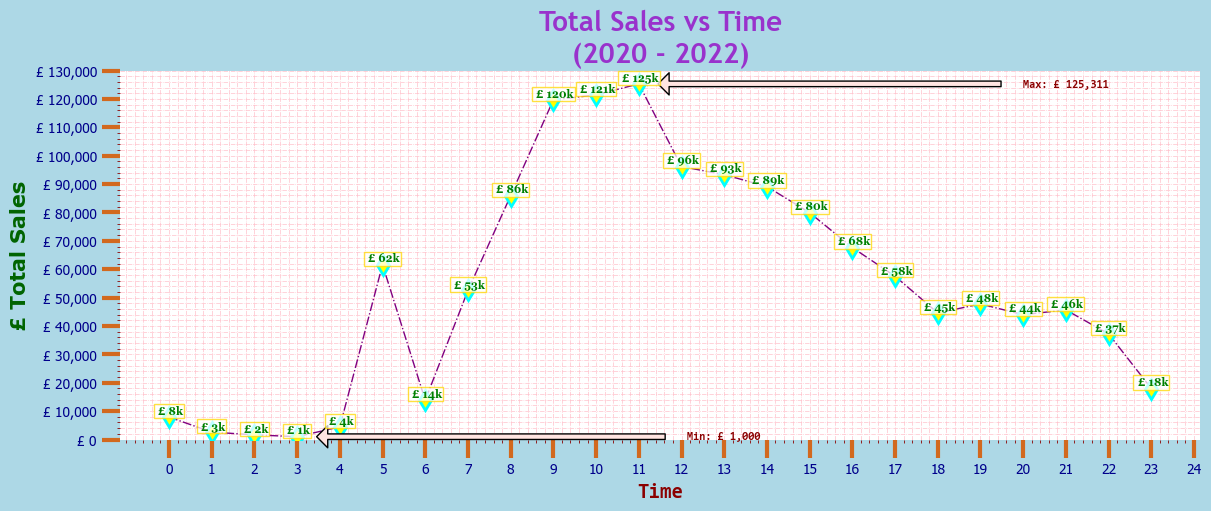

In [77]:
yvalues = df16['total_sales']
xvalues = df16['time']

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

plt.plot(xvalues,yvalues,label=xvalues,marker='d',markersize=10,markeredgecolor='cyan',markeredgewidth=2,markerfacecolor='yellow',linestyle='dashdot',color='purple',linewidth=1)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
plt.yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000])
plt.xlabel('Time',loc='center',fontdict=x_label_font)
plt.ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='both',colors='chocolate',direction='out',length=13,width=3,labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma')
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=True)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales vs Time\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.ylim(0,130000)

# Automatically Annotate The Minumum & Maximum Value

# Find index of minumum value
min_index=np.argmin(yvalues)
# Get the x and y values at the minimum index
min_x = xvalues[min_index]
min_y = yvalues[min_index]

# Find index of maximun value
max_index=np.argmax(yvalues)
# Get the x and y values at the maximum index
max_x = xvalues[max_index]
max_y = yvalues[max_index]

# Annotate the minimum value in the plot
ax.annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot
ax.annotate(f'Max: £ {max_y:,.0f}',xy=(max_x,max_y),xytext=(max_x+10,max_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in bbox square format
for x, yvalues in zip(xvalues,yvalues):
     ax.text(x, yvalues,f" £ {yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
             bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
plt.show()

In [78]:
df17=df.groupby(['api_client_title']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.reset_index()\
.head(10)\
.rename(columns={'sum':'total_sales'})
df17['pct_total_sales'] = df17['total_sales']/df17['total_sales'].sum()
df17.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.

,api_client_title,min,median,max,mean,count,total_sales,pct_total_sales
0,Buy Button,£ -5,£ 0,£ 50,£ 8,20,£ 155,0.01%
1,Draft Orders,£ -35,£ 0,"£ 4,174",£ 20,"1,095","£ 22,114",1.68%
2,GUSTATORY,£ 0,£ 7,£ 349,£ 41,25,"£ 1,030",0.08%
3,Online Store,"£ -3,984",£ 8,"£ 4,250",£ 16,"57,562","£ 900,607",68.29%
4,Recurring Billing by Recharge,£ -138,£ 0,£ 576,£ 8,"18,218","£ 143,486",10.88%
5,Syncio Multi Store Sync,£ 0,£ 6,£ 24,£ 9,32,£ 272,0.02%
6,Wholesale,£ -520,£ 11,"£ 1,014",£ 50,"4,994","£ 251,179",19.05%


### Bar Graph.

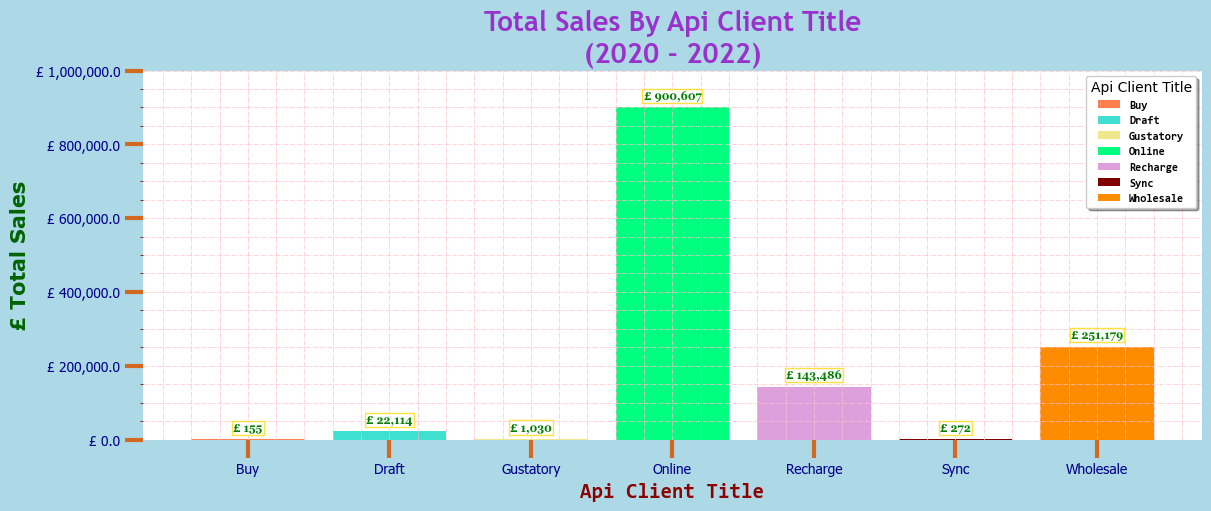

In [79]:
yvalues = df17['total_sales']
xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

plt.bar(xvalues,yvalues,label=xvalues,color=bar_colours)
plt.xlabel('Api Client Title',loc='center',fontdict=x_label_font)
plt.ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='both',colors='chocolate',direction='out',length=13,width=3,labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma')
plt.tick_params(axis='x',which='minor',color='darkred',bottom=False)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=True)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
plt.ylim(0,1000000)

# Annotate y-values in bbox square format
for c in ax.containers:
     ax.bar_label(c,fmt='£ {:,.0f}',label_type='edge',padding=4,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
plt.show()

### Horizontal Bar Graph

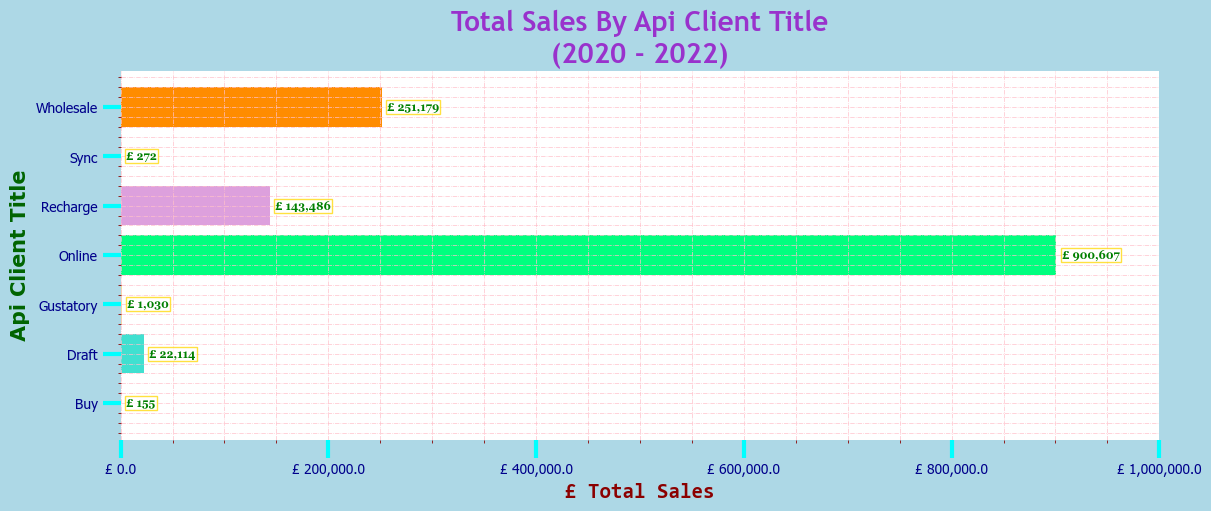

In [80]:
yvalues = df17['total_sales']
xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']

bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

plt.barh(xvalues,yvalues,align='center',color=bar_colours)
plt.xlabel('£ Total Sales',loc='center',fontdict=x_label_font)
plt.ylabel('Api Client Title',loc='center',fontdict=y_label_font)
ax.xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='x',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='y',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=True)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.xlim(0,1000000)

# Annotate y-values in bbox square format
for c in ax.containers:
     ax.bar_label(c,fmt='£ {:,.0f}',label_type='edge',padding=4,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
     
plt.show()


### Stackplot

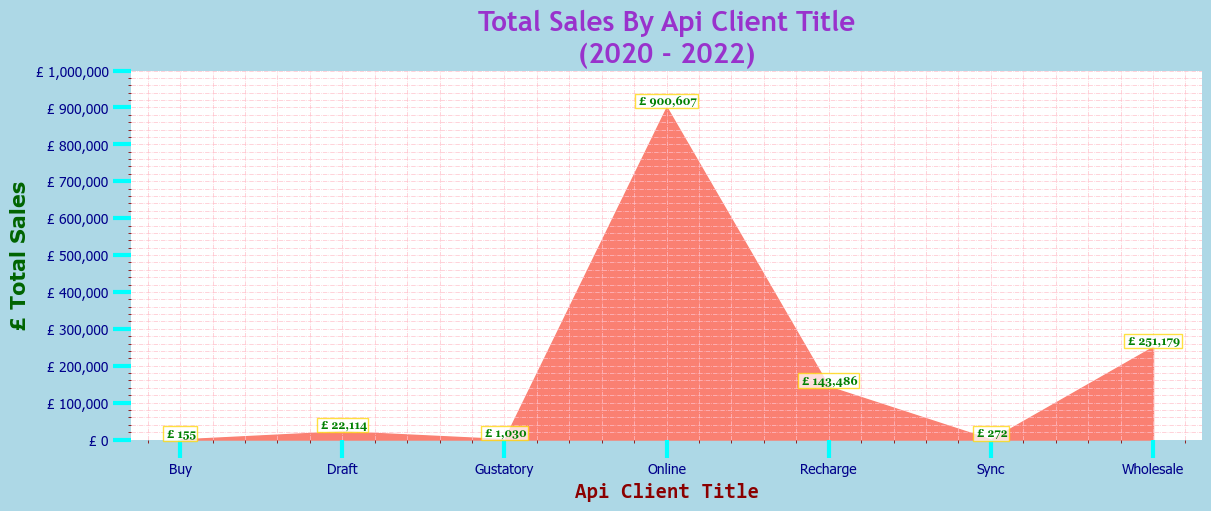

In [81]:
yvalues = df17['total_sales']
xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']

stackplot_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

plt.stackplot(xvalues,yvalues,labels=xvalues,color='salmon',hatch=None,baseline='zero',data=None)
plt.yticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,1000000])
plt.xlabel('Api Client Title',loc='center',fontdict=x_label_font)
plt.ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='x',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='y',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=True)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.ylim(0,1000000)

# Annotate y-values in bbox square format
for x, yvalues in zip(xvalues, yvalues):
     ax.text(x,yvalues,f" £ {yvalues:,.0f}",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
             bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))

plt.show()


### Pie Chart.

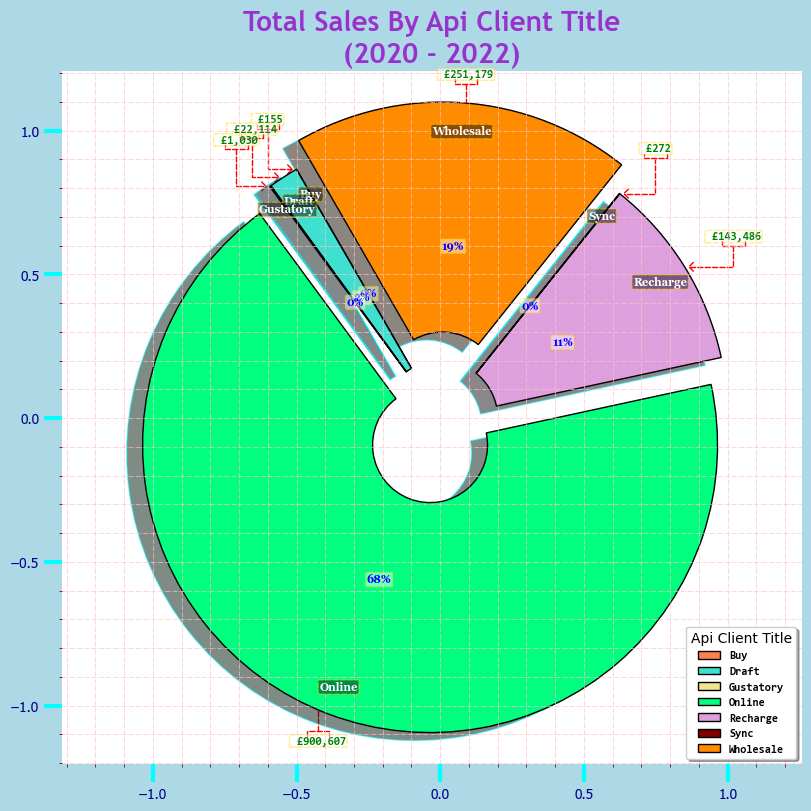

In [82]:
yvalues = df17['total_sales']
xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']

title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}

pie_text = {'ha':'center','va':'center','family':'georgia','color':'darkblue','size':8,'style':'normal','weight':'bold'}
pie_shape = {"linewidth":1,'width':0.8,"edgecolor":"k"}
pie_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
pie_shadow = {'ox':-0.04,'edgecolor':'cyan','shade':0.9}
myexplode = (0,0,0,0.1,0,0,0.1)

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(8,8),layout='constrained',facecolor='lightblue',dpi=100)

wedges, texts, autotexts = plt.pie(yvalues,labels=xvalues,autopct='%.0f%%',textprops=pie_text,wedgeprops=pie_shape,radius=1,frame=True,
pctdistance=0.5,labeldistance=0.9,colors=pie_colours,explode=myexplode,shadow=pie_shadow,startangle=120)

plt.tick_params(axis='x',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='y',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=False)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.legend(title='Api Client Title',loc='lower right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
plt.autoscale()
plt.axis('equal')


for i, wedge in enumerate(wedges):
    # Get the angle of the wedge's center
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.radians(angle))
    y = np.sin(np.radians(angle))
    
    # Define the annotation position
    ann_x = 1.2 * x
    ann_y = 1.2 * y

# Draw the arrow
    bbox_props = dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45) 
    kw = dict(arrowprops=dict(arrowstyle="]->",color='red',mutation_aspect=2,linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=1,
    connectionstyle='angle,angleA=-90,angleB=180,rad=0'),bbox=bbox_props,zorder=0,)

# Annotate y-values in arrow format
    ax.annotate(f' £{yvalues[i]:,.0f}',xy=(x, y),xycoords='data',xytext=(ann_x, ann_y),textcoords='data',
    ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='green',rotation=0,**kw)

# Annotate each wedge with its category label in bbox round format
for i, text in enumerate(texts):
    bbox_props = dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45)
    text.set_bbox(bbox_props)
    text.set_backgroundcolor('black')
    text.set_color('white')

# Annotate each wedge with its x-value/percentage in bbox round format
for autotext in autotexts:
    bbox_props = dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45)
    autotext.set_bbox(bbox_props)
    autotext.set_backgroundcolor('white')
    autotext.set_color('blue')
 
plt.show()


### Scatter Plot Graph.

In [83]:
df18=df.groupby(['time','api_client_title']).total_sales.aggregate(['min','median','max','mean','count','sum'])\
.reset_index()\
.rename(columns={'sum':'total_sales'})
df18['pct_total_sales'] = df18['total_sales']/df18['total_sales'].sum()
df18.style.format({"min": "£ {:,.0f}","median": "£ {:,.0f}","max": "£ {:,.0f}","mean": "£ {:,.0f}","count": "{:,.0f}","total_sales": "£ {:,.0f}","pct_total_sales":"{:,.2%}"},na_rep="")\
.background_gradient(subset=['min'],cmap='Set3')\
.background_gradient(subset=['median'],cmap='cividis')\
.background_gradient(subset=['max'],cmap='viridis')\
.background_gradient(subset=['mean'],cmap='winter')\
.background_gradient(subset=['count'],cmap='autumn')\
.background_gradient(subset=['total_sales'],cmap='summer')\
.background_gradient(subset=['pct_total_sales'],cmap='spring')\
.map(highlight_negative_values)#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='openpyxl')
#.to_excel(r"\Users\tailb\Python-Documents\os\Excel Files\Excel_file2.xlsx",sheet_name='Test1',index=False,header=True,engine='xlsxwriter')
# The index parameter set to False excludes the row index from the output. The headeer parameter set to FALSE excludes the headers from the output.


,time,api_client_title,min,median,max,mean,count,total_sales,pct_total_sales
0,0,Buy Button,£ 0,£ 10,£ 20,£ 10,2,£ 20,0.00%
1,0,Online Store,£ 0,£ 8,£ 235,£ 13,526,"£ 6,657",0.50%
2,0,Recurring Billing by Recharge,£ 0,£ 8,£ 161,£ 18,22,£ 389,0.03%
3,0,Wholesale,£ 0,£ 0,£ 391,£ 32,27,£ 858,0.07%
4,1,Online Store,£ 0,£ 8,£ 74,£ 11,207,"£ 2,238",0.17%
5,1,Recurring Billing by Recharge,£ 0,£ 2,£ 96,£ 19,20,£ 383,0.03%
6,1,Wholesale,£ 0,£ 0,£ 0,£ 0,3,£ 0,0.00%
7,2,Online Store,£ 0,£ 10,£ 118,£ 15,97,"£ 1,460",0.11%
8,2,Recurring Billing by Recharge,£ 0,£ 0,£ 0,£ 0,10,£ 0,0.00%
9,2,Wholesale,£ 11,£ 94,£ 178,£ 94,2,£ 189,0.01%


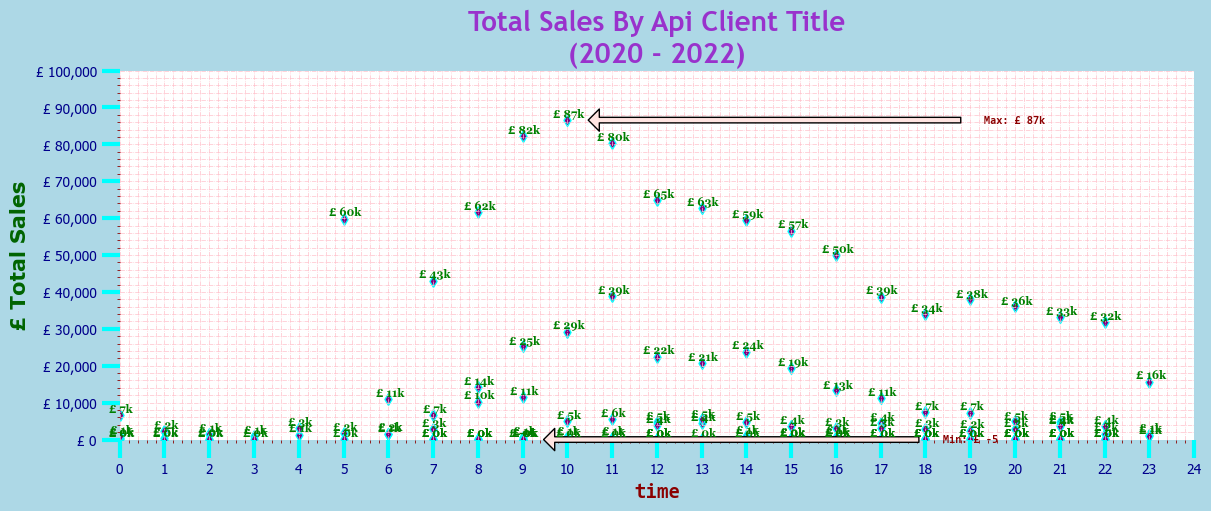

In [84]:
yvalues=df18['total_sales']
xvalues=df18['time']

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

plt.scatter(xvalues,yvalues,label=xvalues,marker='d',edgecolor='cyan',color='purple',linewidths=1)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
plt.yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000])
plt.xlabel('time',loc='center',fontdict=x_label_font)
plt.ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='x',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='y',length=13,width=3,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=1.5)
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=False)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
plt.title('Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.xlim(0,24)
plt.ylim(0,100000)

# Automatically Annotate the Minimun & Maximum Value.

# Find index of minumum value
min_index=np.argmin(yvalues)
# Get the x and y values at the minimum index
min_x = xvalues[min_index]
min_y = yvalues[min_index]

# Find index of maximun value
max_index=np.argmax(yvalues)
# Get the x and y values at the maximum index
max_x = xvalues[max_index]
max_y = yvalues[max_index]

# Annotate the minimum value in the plot.
ax.annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot.
ax.annotate(f'Max: £ {max_y/1000:,.0f}k',xy=(max_x,max_y),xytext=(max_x+10,max_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in text format
for x, yvalues in zip(xvalues, yvalues):
     ax.text(x,yvalues,f" £ {yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0)

plt.show()

### BOXPLOT

In [85]:
# Inspect the unique values in the 'day' column
unique_days = df['day'].unique()
print("Unique days in the dataset:", unique_days)

Unique days in the dataset: ['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday']


In [86]:
# Accessing the MultiIndex columns correctly & Collecting data for each day
matplot_boxplot = df.copy()
matplot_boxplot
matplot_boxplot['index'] = matplot_boxplot.index

#==#

# Pivot the DataFrame
data_day = matplot_boxplot.pivot(index='index', columns='day', values='total_sales')

# Inspect the columns of the pivoted DataFrame
print(data_day.columns)

# Accessing the MultiIndex columns correctly
days = ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
# Filter only the days present in the DataFrame
days_present = [day for day in days if day in data_day.columns]

# Collecting data for each day
l = [data_day[day].dropna() for day in days_present]
l

Index(['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday'],
      dtype='object', name='day')


[index
 68       35.00
 69       20.35
 70       30.00
 71        8.70
 72        9.70
          ...  
 81616    10.00
 81617     0.00
 81618     8.20
 81619     8.20
 81620     0.00
 Name: Friday, Length: 10653, dtype: float64,
 index
 183        8.5
 184        7.5
 185        0.0
 186        9.5
 187       55.8
          ...  
 81941    304.2
 81942     39.0
 81943     22.0
 81944     61.8
 81945     39.8
 Name: Monday, Length: 14993, dtype: float64,
 index
 110       3.05
 111      22.50
 112       0.00
 113       3.00
 114       0.00
          ...  
 81697    32.00
 81698     0.00
 81699     0.00
 81700    42.00
 81701     0.00
 Name: Saturday, Length: 8545, dtype: float64,
 index
 143       9.00
 144       3.65
 145       0.00
 146       3.05
 147       8.50
          ...  
 81820     5.00
 81821    10.00
 81822     0.00
 81823     8.70
 81824     8.00
 Name: Sunday, Length: 10397, dtype: float64,
 index
 31         3.65
 32         7.70
 33         3.65
 34         7.50
 35     

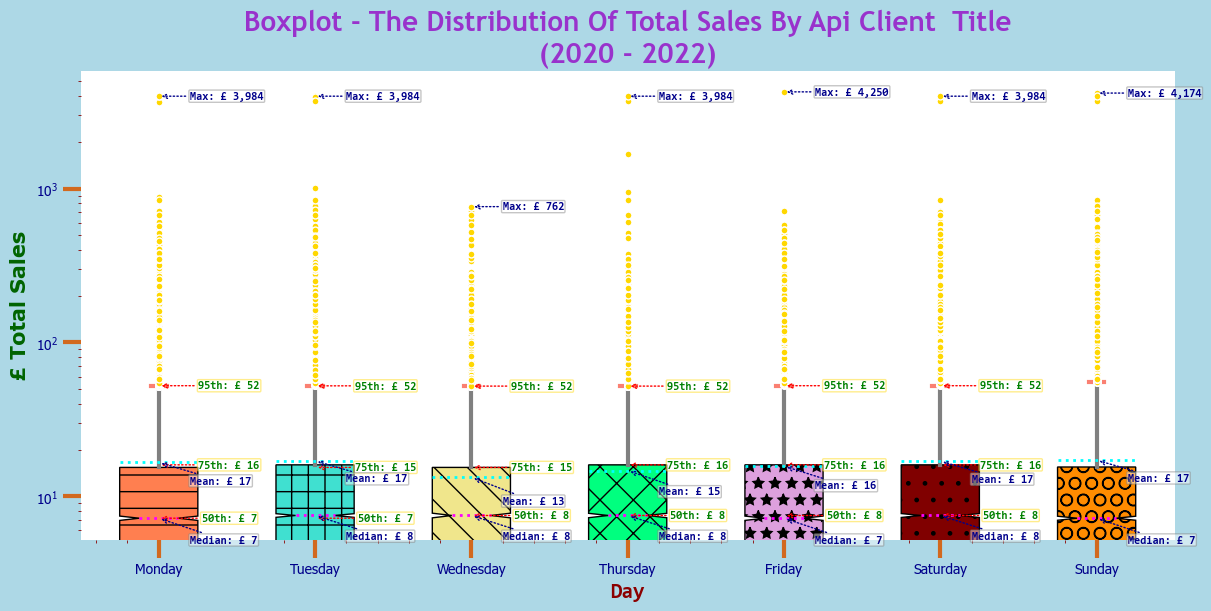

In [87]:
x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}
labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
boxplot_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
boxplot_hatchs = ['-', '+', '\\','x','*','.','O']

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,6),layout='constrained',facecolor='lightblue',dpi=100)

gold_flier = dict(marker='o',markerfacecolor='gold',markeredgecolor='white',markersize=5)
salmon_cap = dict(color='salmon',linewidth=3,linestyle='solid')
grey_whisker = dict(color='grey',linewidth=3,linestyle='solid')
cyan_mean = dict(color='cyan',linewidth=2,linestyle='dotted')
magenta_median = dict(color='magenta',linewidth=2,linestyle='dotted')
black_box = dict(edgecolor='black',linewidth=1,linestyle='solid')

boxplot_style = dict(flierprops=gold_flier,capprops=salmon_cap,whiskerprops=grey_whisker,meanprops=cyan_mean,medianprops=magenta_median,boxprops=black_box)

boxplot = plt.boxplot(l,notch=True,sym=None,vert=True,whis=[0,95],positions=None,widths=None,patch_artist=True,bootstrap=None,**boxplot_style,
usermedians=None,conf_intervals=None,meanline=True,showmeans=True,manage_ticks=True,autorange=False,zorder=None,capwidths=0.1,labels=labels,data=l)

# Assign colors to each box in the boxplot
for box, color, hatch in zip(boxplot['boxes'],boxplot_colours,boxplot_hatchs):
    box.set_facecolor(color)
    box.set(hatch=hatch)

plt.xlabel('Day',loc='center',fontdict=x_label_font)
plt.ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
plt.tick_params(axis='both',colors='chocolate',direction='out',length=13,width=3,labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma')
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=False)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(color='white',linestyle='dashed',linewidth=0.5)
plt.title('Boxplot - The Distribution Of Total Sales By Api Client  Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
plt.yscale('log')

# Annotate the boxplot with percentiles in arrows format
percentiles = [5, 25, 50, 75, 95]
for i, category in enumerate(matplot_boxplot['day'].unique()):
    subset = matplot_boxplot[matplot_boxplot['day'] == category]['total_sales']
    for percentile in percentiles:
        #value = np.percentile(subset, percentile)
        value = np.percentile(subset.dropna(), percentile)
        # Annotate the percentiles on the plot
        ax.annotate(f'{percentile}th: £ {value:,.0f}',xy=(i, value),xytext=(i+0.45, value),
        ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.45,edgecolor='gold'),
        arrowprops=dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,
        connectionstyle='angle3,angleA=90,angleB=0')) # "]->" - 'angle,angleA=-90,angleB=180,rad=0', "->" - 'angle3,angleA=90,angleB=0', 'arc=3,rad=0'

# Annotating the boxplot with min, max, median, and mean values
for i, data in enumerate(l):
    mean_val = np.mean(data)
    median_val = np.median(data)
    min_val = np.min(data)
    max_val = np.max(data)

    arrow = dict(arrowstyle="->",color='darkblue',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
    box=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.45,edgecolor='grey')

# Plot arrows
    ax.annotate(f'Min: £ {min_val:,.0f}',xy=(i+1,min_val),xytext=(i+1+0.2,min_val-1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax.annotate(f'Max: £ {max_val:,.0f}',xy=(i+1,max_val),xytext=(i+1+0.2,max_val+1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax.annotate(f'Median: £ {median_val:,.0f}',xy=(i+1,median_val),xytext=(i+1+0.2,median_val-2),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax.annotate(f'Mean: £ {mean_val:,.0f}', xy=(i+1,mean_val), xytext=(i+1+0.2, mean_val-4),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0, arrowprops=arrow,bbox=box)

plt.show()

### Histogram Graph.
- Creating Bins for our Data and Plotting how values fall into those bins.

In [88]:
pctl_5=df['total_sales'].quantile(0.05)
pctl_25=df['total_sales'].quantile(0.25)
pctl_50=df['total_sales'].quantile(0.5)
pctl_75=df['total_sales'].quantile(0.75)
pctl_95=df['total_sales'].quantile(0.95)

print(f'5th percentile: \t £ {pctl_5:,.0f}')
print(f'25th percentile:\t £ {pctl_25:,.0f}')
print(f'50th percentile: \t £ {pctl_50:,.0f}')
print(f'75th percentile: \t £ {pctl_75:,.0f}')
print(f'95th percentile: \t £ {pctl_95:,.0f}\n')

#==#

min_total_sales = df['total_sales'].min()
max_total_sales = df['total_sales'].max()
mode_total_sales = df['total_sales'].mode()
median_total_sales = df['total_sales'].median()
mean_total_sales = df['total_sales'].mean() 
range_total_sales = (max_total_sales)-(min_total_sales)

print(f'Min Total Sale: \t £ {min_total_sales:,.0f}')
print(f'Max Total Sale: \t £ {max_total_sales:,.0f}')
print(f'Median Total Sale:\t £ {median_total_sales:,.0f}')
print(f'Mean Total Sale:\t £ {mean_total_sales:,.0f}')
#print(f'Mode Total Sale: \t £ {mode_total_sales:,.0f}')
print(f'Range Total Sale: \t £ {range_total_sales:,.0f}')


5th percentile: 	 £ 0
25th percentile:	 £ 0
50th percentile: 	 £ 8
75th percentile: 	 £ 16
95th percentile: 	 £ 52

Min Total Sale: 	 £ -3,984
Max Total Sale: 	 £ 4,250
Median Total Sale:	 £ 8
Mean Total Sale:	 £ 16
Range Total Sale: 	 £ 8,234


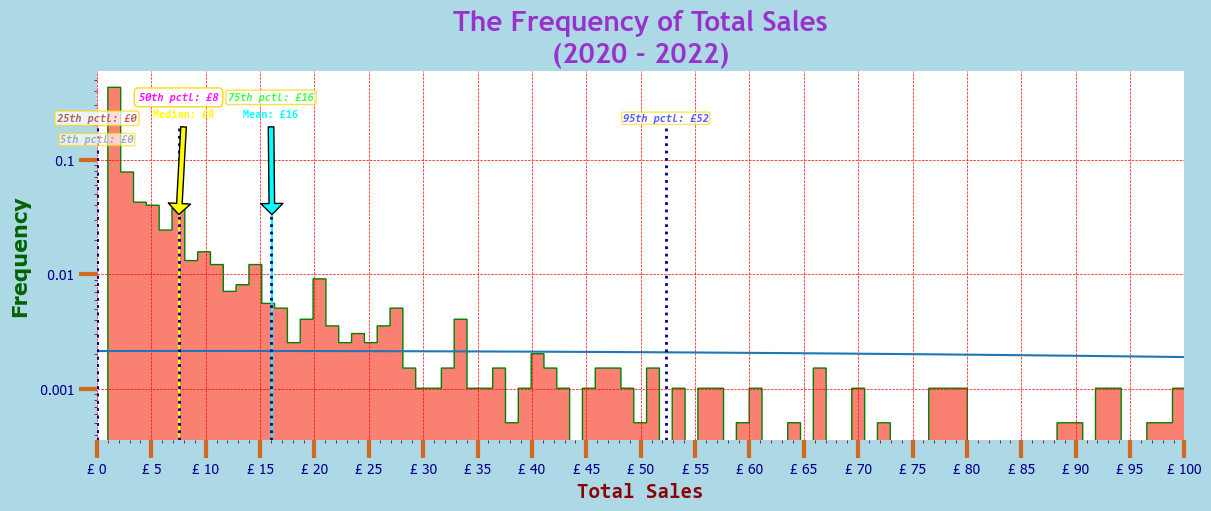

In [89]:
# Counts of unique values
histogram = df['total_sales'].value_counts()

# Calculate quantile/percentile values
pctl_5=df['total_sales'].quantile(0.05)
pctl_25=df['total_sales'].quantile(0.25)
pctl_50=df['total_sales'].quantile(0.5)
pctl_75=df['total_sales'].quantile(0.75)
pctl_95=df['total_sales'].quantile(0.95)

# Calculate statistical values
mean_total_sales = df['total_sales'].mean() 
mode_total_sales = df['total_sales'].mode()
median_total_sales = df['total_sales'].median()
min_total_sales = df['total_sales'].min()
max_total_sales = df['total_sales'].max()
range_total_sales = (max_total_sales)-(min_total_sales)

# Create bins for the histogram
bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170]

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(12,5),layout='constrained',facecolor='lightblue',dpi=100)

bar = plt.hist(x=histogram,bins='auto',density=True,histtype='stepfilled',align='mid',orientation='vertical',rwidth=0.95,log=True,color='salmon',label=None,stacked=False,data=None,
edgecolor='green')
plt.xlabel('Total Sales',loc='center',fontdict=x_label_font)
plt.xticks([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,])
plt.ylabel('Frequency',loc='center',fontdict=y_label_font)
ax.xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax.yaxis.set_major_formatter(StrMethodFormatter(' {x:,}'))
plt.tick_params(axis='both',colors='chocolate',direction='out',length=13,width=3,labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma')
plt.tick_params(axis='x',which='minor',color='darkred',bottom=True)
plt.tick_params(axis='y',which='minor',color='darkred',bottom=False)
plt.minorticks_on()
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_visible(False)
ax.set_facecolor('white')
plt.grid(color='red',linestyle='dashed',linewidth=0.5)
plt.title('The Frequency of Total Sales\n' + '(2020 - 2022)',loc='center',fontweight='bold',fontdict=title_font)
ax.set_xlim(0,100)

min = min_total_sales
max = max_total_sales
median = median_total_sales
mean = mean_total_sales
mode = mode_total_sales
range= range_total_sales

ax.vlines([min],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='red',)
ax.vlines([max],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='lime',)
ax.vlines([median],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='yellow',)
ax.vlines([mean],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='cyan',)
ax.vlines([range],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='grey',)

#Add KDE on to a histogram
kde = stats.gaussian_kde(histogram)
xx = np.linspace(0, 100)
ax.plot(xx, kde(xx))

# Calculate percentiles
quant_5, quant_25, quant_50, quant_75, quant_95 = \
df['total_sales'].quantile(0.05),df['total_sales'].quantile(0.25), df['total_sales'].quantile(0.5),df['total_sales'].quantile(0.75),df['total_sales'].quantile(0.95)
# [quantile, opacity/transparency, length]
quants = [[quant_5, 1, 0.85], [quant_25, 1, 0.85], [quant_50, 1, 0.85],  [quant_75, 1, 0.85], [quant_95, 1, 0.85]]

# Plot the lines with a loop
for i in quants:
    ax.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = "dotted", linewidth=2, color = 'darkblue')

pctl_5_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='grey',rotation=0,alpha=0.65)
pctl_25_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='brown',rotation=0,alpha=0.75)
pctl_50_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='magenta',rotation=0,alpha=0.95)
pctl_75_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='lime',rotation=0,alpha=0.75)
pctl_95_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='blue',rotation=0,alpha=0.65)

# Annotate percentiles & values to axes in bbbox format
ax.text(quant_5,0.15,f'5th pctl: £{pctl_5:,.0f}',fontdict=pctl_5_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))
ax.text(quant_25,0.23,f'25th pctl: £{pctl_25:,.0f}',fontdict=pctl_25_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
ax.text(quant_50,0.35,f'50th pctl: £{pctl_50:,.0f}',fontdict=pctl_50_fontdict,bbox=dict(boxstyle="round",pad=0.4,facecolor='white',edgecolor='gold',alpha=0.95,))
ax.text(quant_75,0.35,f'75th pctl: £{pctl_75:,.0f}',fontdict=pctl_75_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
ax.text(quant_95,0.23,f'95th pctl: £{pctl_95:,.0f}',fontdict=pctl_95_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))

# Annotate Median & Mean to axes in arrow format
ax.annotate(f'Median: £{median:,.0f}',xy=(median,0.03),xytext=(8,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='yellow',rotation=0,
arrowprops=dict(facecolor='yellow',headwidth=16,headlength=8,width=4,shrink=0.05))

ax.annotate(f'Mean: £{mean:,.0f}',xy=(mean,0.03),xytext=(16,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='cyan',rotation=0,
arrowprops=dict(facecolor='cyan',headwidth=16,headlength=8,width=4,shrink=0.05))

plt.show(close=None,block=None)


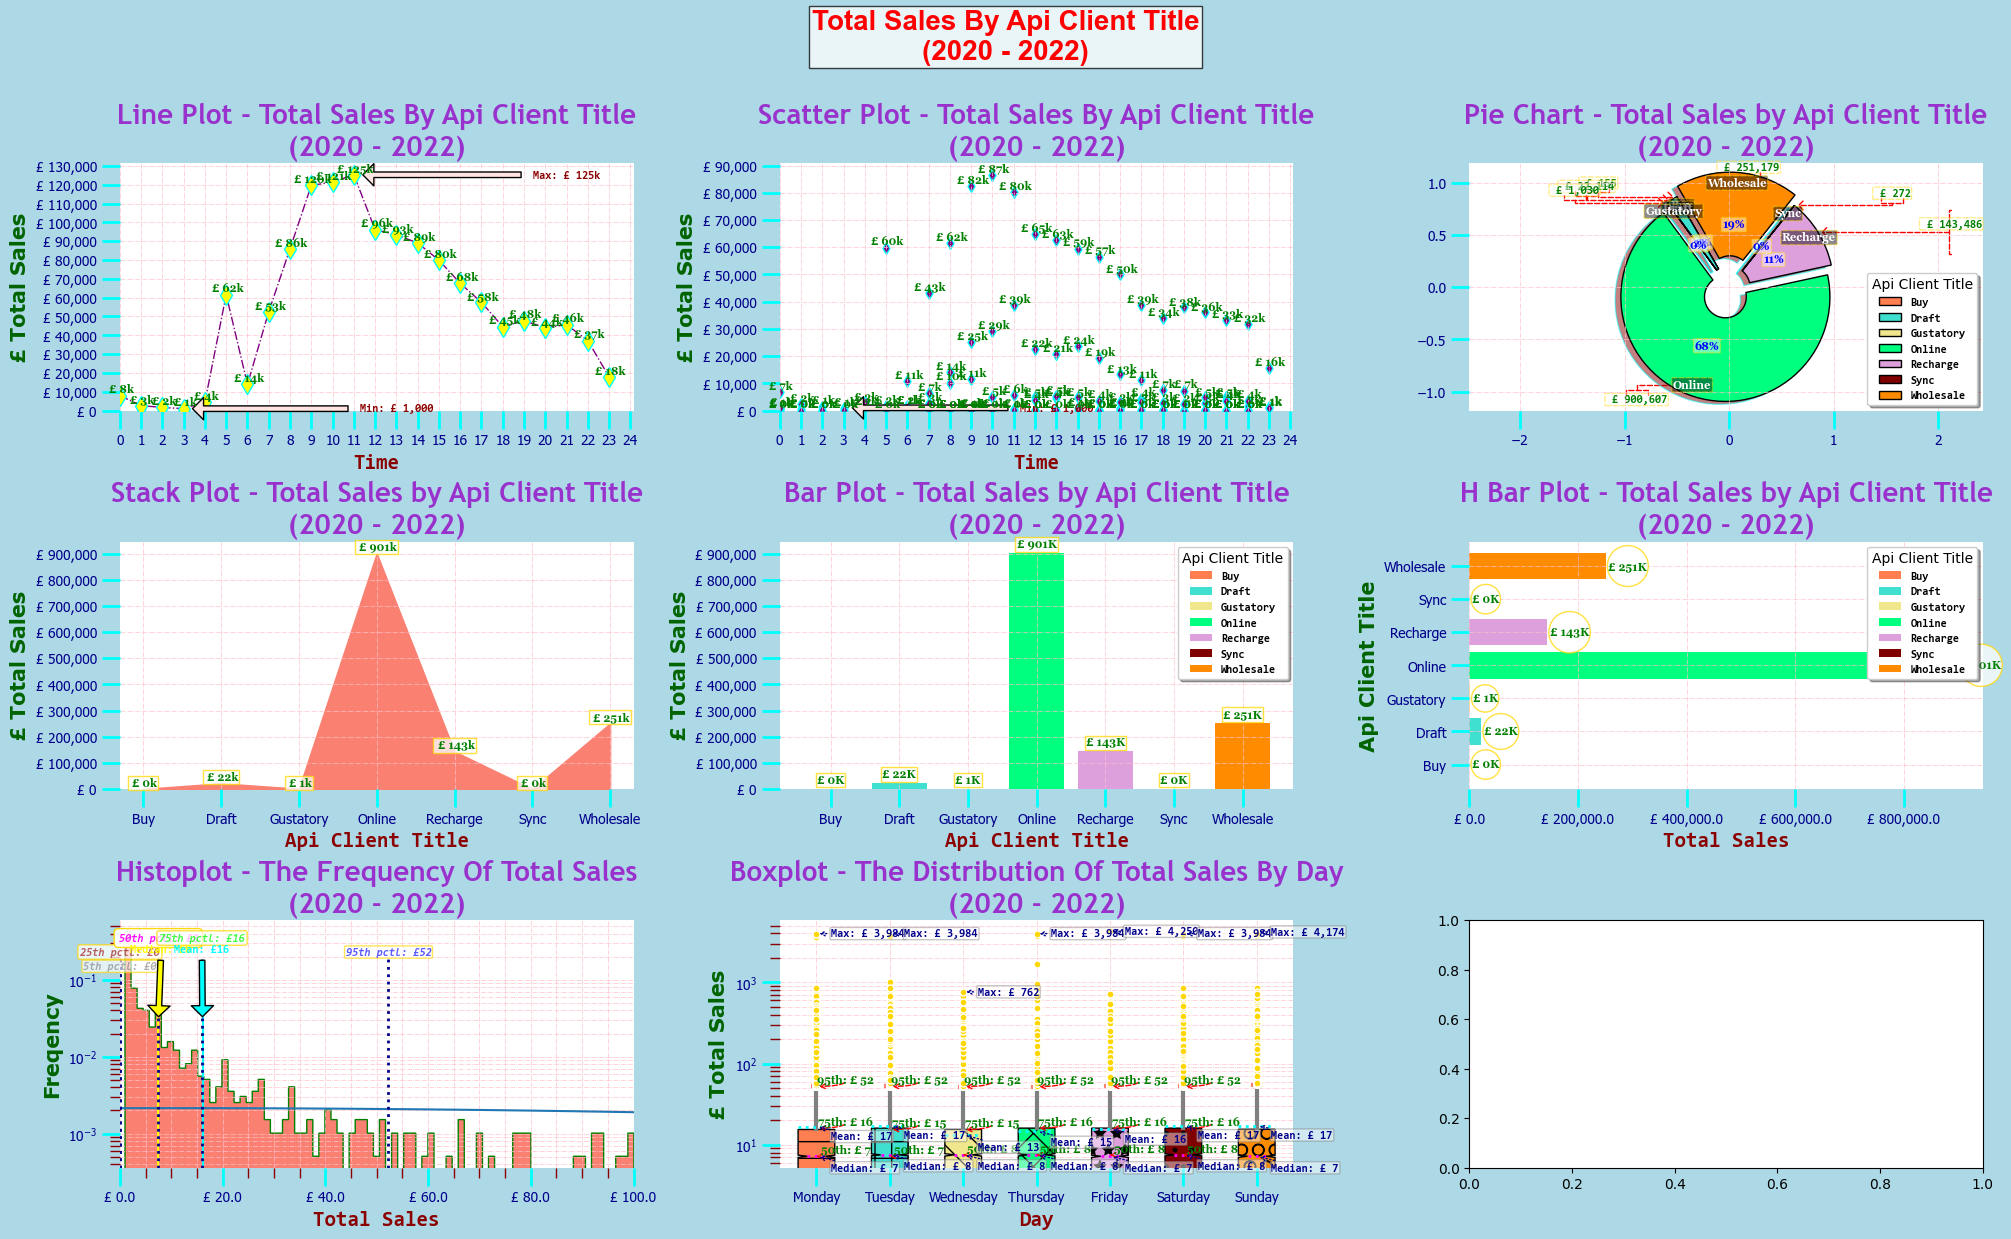

In [90]:
#PLOT SUBPLOTS#
line_yvalues = df16['total_sales']
line_xvalues = df16['time']
# Find index of minumum value
min_index=np.argmin(line_yvalues)
# Get the x and y values at the minimum index
min_x = line_xvalues[min_index]
min_y = line_yvalues[min_index]
# Find index of maximun value
max_index=np.argmax(line_yvalues)
# Get the x and y values at the maximum index
max_x = line_xvalues[max_index]
max_y = line_yvalues[max_index]

#==#
bar_yvalues = df17['total_sales']
#bar_xvalues = df17['api_client_title']
bar_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
pie_yvalues = df17['total_sales']
#pie_xvalues = df17['api_client_title']
pie_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
stack_yvalues = df17['total_sales']
#stack_xvalues = df17['api_client_title']
stack_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
scatter_yvalues=df18['total_sales']
scatter_xvalues=df18['time']
#==#

##

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
subplot_title_font = {'family':'Arial','size':20,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

##

fig, axs = plt.subplots(ncols=3,nrows=3,figsize=(20,12),layout='constrained',facecolor='lightblue')

##

fig.suptitle('Total Sales By Api Client Title\n' + '(2020 - 2022)',ha='center',va='center',color='red',stretch=None,fontproperties=subplot_title_font,
bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='black'))

##

## LINE PLOT ###
axs[0,0].plot(line_xvalues,line_yvalues,label=line_xvalues,marker='d',markersize=10,markeredgecolor='cyan',markerfacecolor='yellow',linestyle='dashdot',color='purple',linewidth=1)
axs[0,0].set_xlabel('Time',loc='center',fontdict=x_label_font)
axs[0,0].set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
axs[0,0].yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[0,0].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
axs[0,0].set_yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000])
axs[0,0].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,0].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,0].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,0].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,0].spines[['top','right']].set_visible(False)
axs[0,0].spines[['bottom','left']].set_visible(False)
axs[0,0].set_facecolor('white')
axs[0,0].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[0,0].set_title('Line Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[0,0].set_xlim(left=0)
axs[0,0].set_ylim(bottom=0)

#==#

# Annotate the minimum value in the plot
axs[0,0].annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot
axs[0,0].annotate(f'Max: £ {max_y/1000:,.0f}k',xy=(max_x,max_y),xytext=(max_x+10,max_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in text format
for x, line_yvalues in zip(line_xvalues, line_yvalues):
     axs[0,0].text(x,line_yvalues,f" £ {line_yvalues/1000:,.0f}k",fontdict=text_font)

#==#

## SCATTER PLOT ##
axs[0,1].scatter(scatter_xvalues,scatter_yvalues,label=scatter_xvalues,marker='d',edgecolor='cyan',color='purple',linewidths=1)
axs[0,1].set_xlabel('Time',loc='center',fontdict=x_label_font)
axs[0,1].set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
axs[0,1].yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[0,1].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
axs[0,1].set_yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000])
axs[0,1].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,1].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,1].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,1].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,1].spines[['top','right']].set_visible(False)
axs[0,1].spines[['bottom','left']].set_visible(False)
axs[0,1].set_facecolor('white')
axs[0,1].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[0,1].set_title('Scatter Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[0,1].set_xlim(left=0)
axs[0,1].set_ylim(bottom=0)

#==#

# Annotate the minimum value in the plot
axs[0,1].annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot
axs[0,1].annotate(f'Max: £ {max_y/1000:,.0f}k',xy=(max_x,max_y),xytext=(max_x+10,max_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in text format
for x, scatter_yvalues in zip(scatter_xvalues, scatter_yvalues ):
     axs[0,1].text(x,scatter_yvalues ,f" £ {scatter_yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0)

#==#

## PIE CHART ##
pie_text = {'ha':'center','va':'center','family':'georgia','color':'darkblue','size':8,'style':'normal','weight':'bold'}
pie_shape = {"linewidth":1,'width':0.8,"edgecolor":"k"}
pie_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
pie_shadow = {'ox':-0.04,'edgecolor':'cyan','shade':0.9,'facecolor':'darkred'}
myexplode = (0,0,0,0.1,0,0,0.1)

wedges, texts, autotexts = axs[0,2].pie(pie_yvalues,labels=pie_xvalues,autopct='%.0f%%',textprops=pie_text,wedgeprops=pie_shape,radius=1,frame=True,center=(0,0),pctdistance=0.5,
labeldistance=0.90,colors=pie_colours,explode=myexplode,shadow=pie_shadow,startangle=120)
axs[0,2].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,2].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[0,2].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,2].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[0,2].spines[['top','right']].set_visible(False)
axs[0,2].spines[['bottom','left']].set_visible(False)
axs[0,2].set_facecolor('white')
axs[0,2].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[0,2].set_title('Pie Chart - Total Sales by Api Client Title\n' + '(2020 - 2022)',loc='center',fontweight='bold',fontdict=title_font)
axs[0,2].legend(title='Api Client Title',loc='lower right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
axs[0,2].axis('equal')

#==#

# Annotate each wedge
for i, wedge in enumerate(wedges):
     # Only annotate if the value is greater than zero
     if pie_yvalues[i] > 0: 
          # Calculate the angle of the wedge's center
          angle = (wedge.theta2 + wedge.theta1) / 2
          #angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1 
          
          # Calculate the position to place the annotation
          x = np.cos(np.radians(angle))
          y = np.sin(np.radians(angle))
          
          ann_x = 2.5 * x # Adjust for desired annotation position - Outwards
          ann_y = 1.15 * y # Adjust for desired annotation position - Upwards
 
#==#

# Draw the arrow
     bbox_props = dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45) 
     kw = dict(arrowprops=dict(arrowstyle="]->",color='red',mutation_aspect=2,linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=1,
     connectionstyle='angle,angleA=-90,angleB=180,rad=0'),bbox=bbox_props,zorder=0,)
    
# Annotate y-values in arrow format
     axs[0,2].annotate(f' £ {pie_yvalues[i]:,.0f}',xy=(x, y),xycoords='data',xytext=(ann_x, ann_y),textcoords='data',
     ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='green',rotation=0,**kw)

# Annotate each wedge with its category label in bbox square format
for i, text in enumerate(texts):
    text.set_bbox(dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45))
    text.set_backgroundcolor('black')
    text.set_color('white')

# Annotate each wedge with its x-value/percentage in bbox round format
for autotext in autotexts:
    autotext.set_bbox(dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45))
    autotext.set_backgroundcolor('white')
    autotext.set_color('blue')

#==#

## STACK PLOT ##
axs[1,0].stackplot(stack_xvalues,stack_yvalues,color='salmon',hatch=None,baseline='zero',data=None)
axs[1,0].set_xlabel('Api Client Title',loc='center',fontdict=x_label_font)
axs[1,0].set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
#axs[1,0].xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[1,0].yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
#axs[1,0].set_xticks([0,1])
axs[1,0].set_yticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,])
#axs[1,0].tick_params(axis='both',colors='chocolate',direction='out',length=13,width=2,labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None)
axs[1,0].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,0].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,0].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,0].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,0].spines[['top','right']].set_visible(False)
axs[1,0].spines[['bottom','left']].set_visible(False)
axs[1,0].set_facecolor('white')
axs[1,0].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[1,0].set_title('Stack Plot - Total Sales by Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[1,0].set_ylim(bottom=0)

#==#
 
# Annotate y-values in bbox square format
for x, stack_yvalues in zip(stack_xvalues, stack_yvalues):
     axs[1,0].text(x,stack_yvalues,f" £ {stack_yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
             bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
     
#==#

## BAR PLOT ##
bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

axs[1,1].bar(bar_xvalues,bar_yvalues,label=bar_xvalues,color=bar_colours)
axs[1,1].set_xlabel('Api Client Title',loc='center',fontdict=x_label_font)
axs[1,1].set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
axs[1,1].yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[1,1].set_yticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,])
axs[1,1].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,1].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,1].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,1].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,1].spines[['top','right']].set_visible(False)
axs[1,1].spines[['bottom','left']].set_visible(False)
axs[1,1].set_facecolor('white')
axs[1,1].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[1,1].set_title('Bar Plot - Total Sales by Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[1,1].legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
axs[1,1].set_ylim(bottom=0)

#==#

# Annotate y-values in bbox square format
for c in axs[1,1].containers:
    labels = [f'£ {(v.get_height() / 1000):,.0f}K' for v in c]
    axs[1,1].bar_label(c,labels=labels,label_type='edge',padding=2,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
#==#

## H-BAR PLOT ##
bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

axs[1,2].barh(bar_xvalues,bar_yvalues,align='center',label=bar_xvalues,color=bar_colours)
axs[1,2].set_xlabel('Total Sales',loc='center',fontdict=x_label_font)
axs[1,2].set_ylabel('Api Client Title',loc='center',fontdict=y_label_font)
axs[1,2].xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[1,2].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,2].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[1,2].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,2].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[1,2].spines[['top','right']].set_visible(False)
axs[1,2].spines[['bottom','left']].set_visible(False)
axs[1,2].set_facecolor('white')
axs[1,2].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[1,2].set_title('H Bar Plot - Total Sales by Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[1,2].legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
axs[1,2].set_xlim(left=0)

#==#

# Annotate values in bbox circle format
for c in axs[1,2].containers:
    labels = [f'£ {(v.get_width() / 1000):,.0f}K' for v in c]
    axs[1,2].bar_label(c, labels=labels, label_type='edge',padding=2,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="circle",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
#==#

## HISTOGRAM ##
histogram = df['total_sales'].value_counts()

# Calculate the min, max, median, mean, mode & range
min_total_sales = df['total_sales'].min()
max_total_sales = df['total_sales'].max()
median_total_sales = df['total_sales'].median()
mean_total_sales = df['total_sales'].mean() 
mode_total_sales = df['total_sales'].mode()
range_total_sales = (max_total_sales)-(min_total_sales)

# Assign bins
bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170]

axs[2,0].hist(x=histogram,bins='auto',density=True,histtype='stepfilled',align='mid',orientation='vertical',rwidth=0.95,log=True,color='salmon',label=None,stacked=False,data=None,
edgecolor='green')
axs[2,0].set_xlabel('Total Sales',loc='center',fontdict=x_label_font)
axs[2,0].set_ylabel('Freqency',loc='center',fontdict=y_label_font)
axs[2,0].xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[2,0].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[2,0].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[2,0].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[2,0].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[2,0].minorticks_on()
axs[2,0].spines[['top','right']].set_visible(False)
axs[2,0].spines[['bottom','left']].set_visible(False)
axs[2,0].set_facecolor('white')
axs[2,0].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[2,0].set_title('Histoplot - The Frequency Of Total Sales\n' + '(2020 - 2022)',loc='center',fontweight='bold',fontdict=title_font)
axs[2,0].set_xlim(0,100)

# Assign new variable names to min, max, median, mean, mode & range
min = min_total_sales
max = max_total_sales
median = median_total_sales
mean = mean_total_sales
mode = mode_total_sales
range= range_total_sales

# Create vertical lines for min, max, median, mean & range
axs[2,0].vlines([min],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='red')
axs[2,0].vlines([max],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='lime')
axs[2,0].vlines([median],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='yellow')
axs[2,0].vlines([mean],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='cyan')
axs[2,0].vlines([range],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='grey')

# Add KDE on to a histogram
kde = stats.gaussian_kde(histogram)
xx = np.linspace(0, 100)
axs[2,0].plot(xx, kde(xx))

# Calculate percentiles
quant_5, quant_25, quant_50, quant_75, quant_95 = \
df['total_sales'].quantile(0.05),df['total_sales'].quantile(0.25), df['total_sales'].quantile(0.5),df['total_sales'].quantile(0.75),df['total_sales'].quantile(0.95)
# [quantile, opacity/transparency, length]
quants = [[quant_5, 1, 0.85], [quant_25, 1, 0.85], [quant_50, 1, 0.85],  [quant_75, 1, 0.85], [quant_95, 1, 0.85]]

# Plot the lines with a loop
for i in quants:
     axs[2,0].axvline(i[0], alpha = i[1], ymax = i[2], linestyle = "dotted", linewidth=2, color = 'darkblue')

# Create Percentile font dictionary
pctl_5_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='grey',rotation=0,alpha=0.65)
pctl_25_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='brown',rotation=0,alpha=0.75)
pctl_50_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='magenta',rotation=0,alpha=0.95)
pctl_75_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='lime',rotation=0,alpha=0.75)
pctl_95_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='blue',rotation=0,alpha=0.65)

# Annotate percentiles & values to axes in bbox round format
axs[2,0].text(quant_5,0.15,f'5th pctl: £{pctl_5:,.0f}',fontdict=pctl_5_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))
axs[2,0].text(quant_25,0.23,f'25th pctl: £{pctl_25:,.0f}',fontdict=pctl_25_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
axs[2,0].text(quant_50,0.35,f'50th pctl: £{pctl_50:,.0f}',fontdict=pctl_50_fontdict,bbox=dict(boxstyle="round",pad=0.4,facecolor='white',edgecolor='gold',alpha=0.95,))
axs[2,0].text(quant_75,0.35,f'75th pctl: £{pctl_75:,.0f}',fontdict=pctl_75_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
axs[2,0].text(quant_95,0.23,f'95th pctl: £{pctl_95:,.0f}',fontdict=pctl_95_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))

# Annotate Median & Mean to axes in arrow format
axs[2,0].annotate(f'Median: £{median:,.0f}',xy=(median,0.03),xytext=(8,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='yellow',rotation=0,
arrowprops=dict(facecolor='yellow',headwidth=16,headlength=8,width=4,shrink=0.05))

axs[2,0].annotate(f'Mean: £{mean:,.0f}',xy=(mean,0.03),xytext=(16,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='cyan',rotation=0,
arrowprops=dict(facecolor='cyan',headwidth=16,headlength=8,width=4,shrink=0.05))

#==#

## BOXPLOT ##
matplot_boxplot = df.copy()
matplot_boxplot
matplot_boxplot['index'] = matplot_boxplot.index

#==#

# Pivot the DataFrame
data_day = matplot_boxplot.pivot(index='index', columns='day', values='total_sales')

# Inspect the columns of the pivoted DataFrame
#print(data_day.columns)

# Accessing the MultiIndex columns correctly
days = ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
# Filter only the days present in the DataFrame
days_present = [day for day in days if day in data_day.columns]

# Collecting data for each day
l = [data_day[day].dropna() for day in days_present]
l

#==#

labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
boxplot_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
boxplot_hatchs = ['-', '+', '\\','x','*','.','O']

#==#

gold_flier = dict(marker='o',markerfacecolor='gold',markeredgecolor='white',markersize=5)
salmon_cap = dict(color='salmon',linewidth=3,linestyle='solid')
grey_whisker = dict(color='grey',linewidth=3,linestyle='solid')
cyan_mean = dict(color='cyan',linewidth=2,linestyle='dotted')
magenta_median = dict(color='magenta',linewidth=2,linestyle='dotted')
black_box = dict(edgecolor='black',linewidth=1,linestyle='solid')

boxplot_style = dict(flierprops=gold_flier,capprops=salmon_cap,whiskerprops=grey_whisker,meanprops=cyan_mean,medianprops=magenta_median,boxprops=black_box)

#==#

boxplot = axs[2,1].boxplot(l,notch=True,sym=None,vert=True,whis=[0,95],positions=None,widths=None,patch_artist=True,bootstrap=None,**boxplot_style,
usermedians=None,conf_intervals=None,meanline=True,showmeans=True,manage_ticks=True,autorange=False,zorder=None,capwidths=0.1,labels=labels,data=l)

axs[2,1].set_xlabel('Day',loc='center',fontdict=x_label_font)
axs[2,1].set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
axs[2,1].yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
axs[2,1].tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[2,1].tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
axs[2,1].tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[2,1].tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
axs[2,0].minorticks_on()
axs[2,1].spines[['top','right']].set_visible(False)
axs[2,1].spines[['bottom','left']].set_visible(False)
axs[2,1].set_facecolor('white')
axs[2,1].grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
axs[2,1].set_title('Boxplot - The Distribution Of Total Sales By Day\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
axs[2,1].set_yscale('log')

#==#

# Annotate the catplot/boxplot with percentiles in arrows format
percentiles = [5, 25, 50, 75, 95]
for i, category in enumerate(matplot_boxplot['day'].unique()):
    subset = matplot_boxplot[matplot_boxplot['day'] == category]['total_sales']
    for percentile in percentiles:
        value = np.percentile(subset, percentile)
        # Annotate the percentiles on the plot
        axs[2,1].annotate(f'{percentile}th: £ {value:,.0f}',xy=(i,value),xytext=(i+0.40,value),
        ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
        #bbox=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'),
        arrowprops=dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=1,
        connectionstyle='angle3,angleA=90,angleB=0')) # "]->" - 'angle,angleA=-90,angleB=180,rad=0', "->" - 'angle3,angleA=90,angleB=0'

#==#

# Assign colors to each box in the boxplot
for box, color, hatch in zip(boxplot['boxes'],boxplot_colours,boxplot_hatchs):
    box.set_facecolor(color)
    box.set(hatch=hatch)

#==#

# Annotate the boxplot with min, max, median, and mean values
for i, data in enumerate(l):
    mean_val = np.mean(data)
    median_val = np.median(data)
    min_val = np.min(data)
    max_val = np.max(data)

#==#

    arrow = dict(arrowstyle="->",color='darkblue',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
    box=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.45,edgecolor='grey')

#==#

# Plot arrows
    axs[2,1].annotate(f'Min: £ {min_val:,.0f}',xy=(i+1,min_val),xytext=(i+1+0.2,min_val-1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    axs[2,1].annotate(f'Max: £ {max_val:,.0f}',xy=(i+1,max_val),xytext=(i+1+0.2,max_val+1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    axs[2,1].annotate(f'Median: £ {median_val:,.0f}',xy=(i+1,median_val),xytext=(i+1+0.2,median_val-2),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    axs[2,1].annotate(f'Mean: £ {mean_val:,.0f}', xy=(i+1,mean_val), xytext=(i+1+0.2, mean_val-4),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0, arrowprops=arrow,bbox=box)

#==#

plt.show(close=None,block=None)

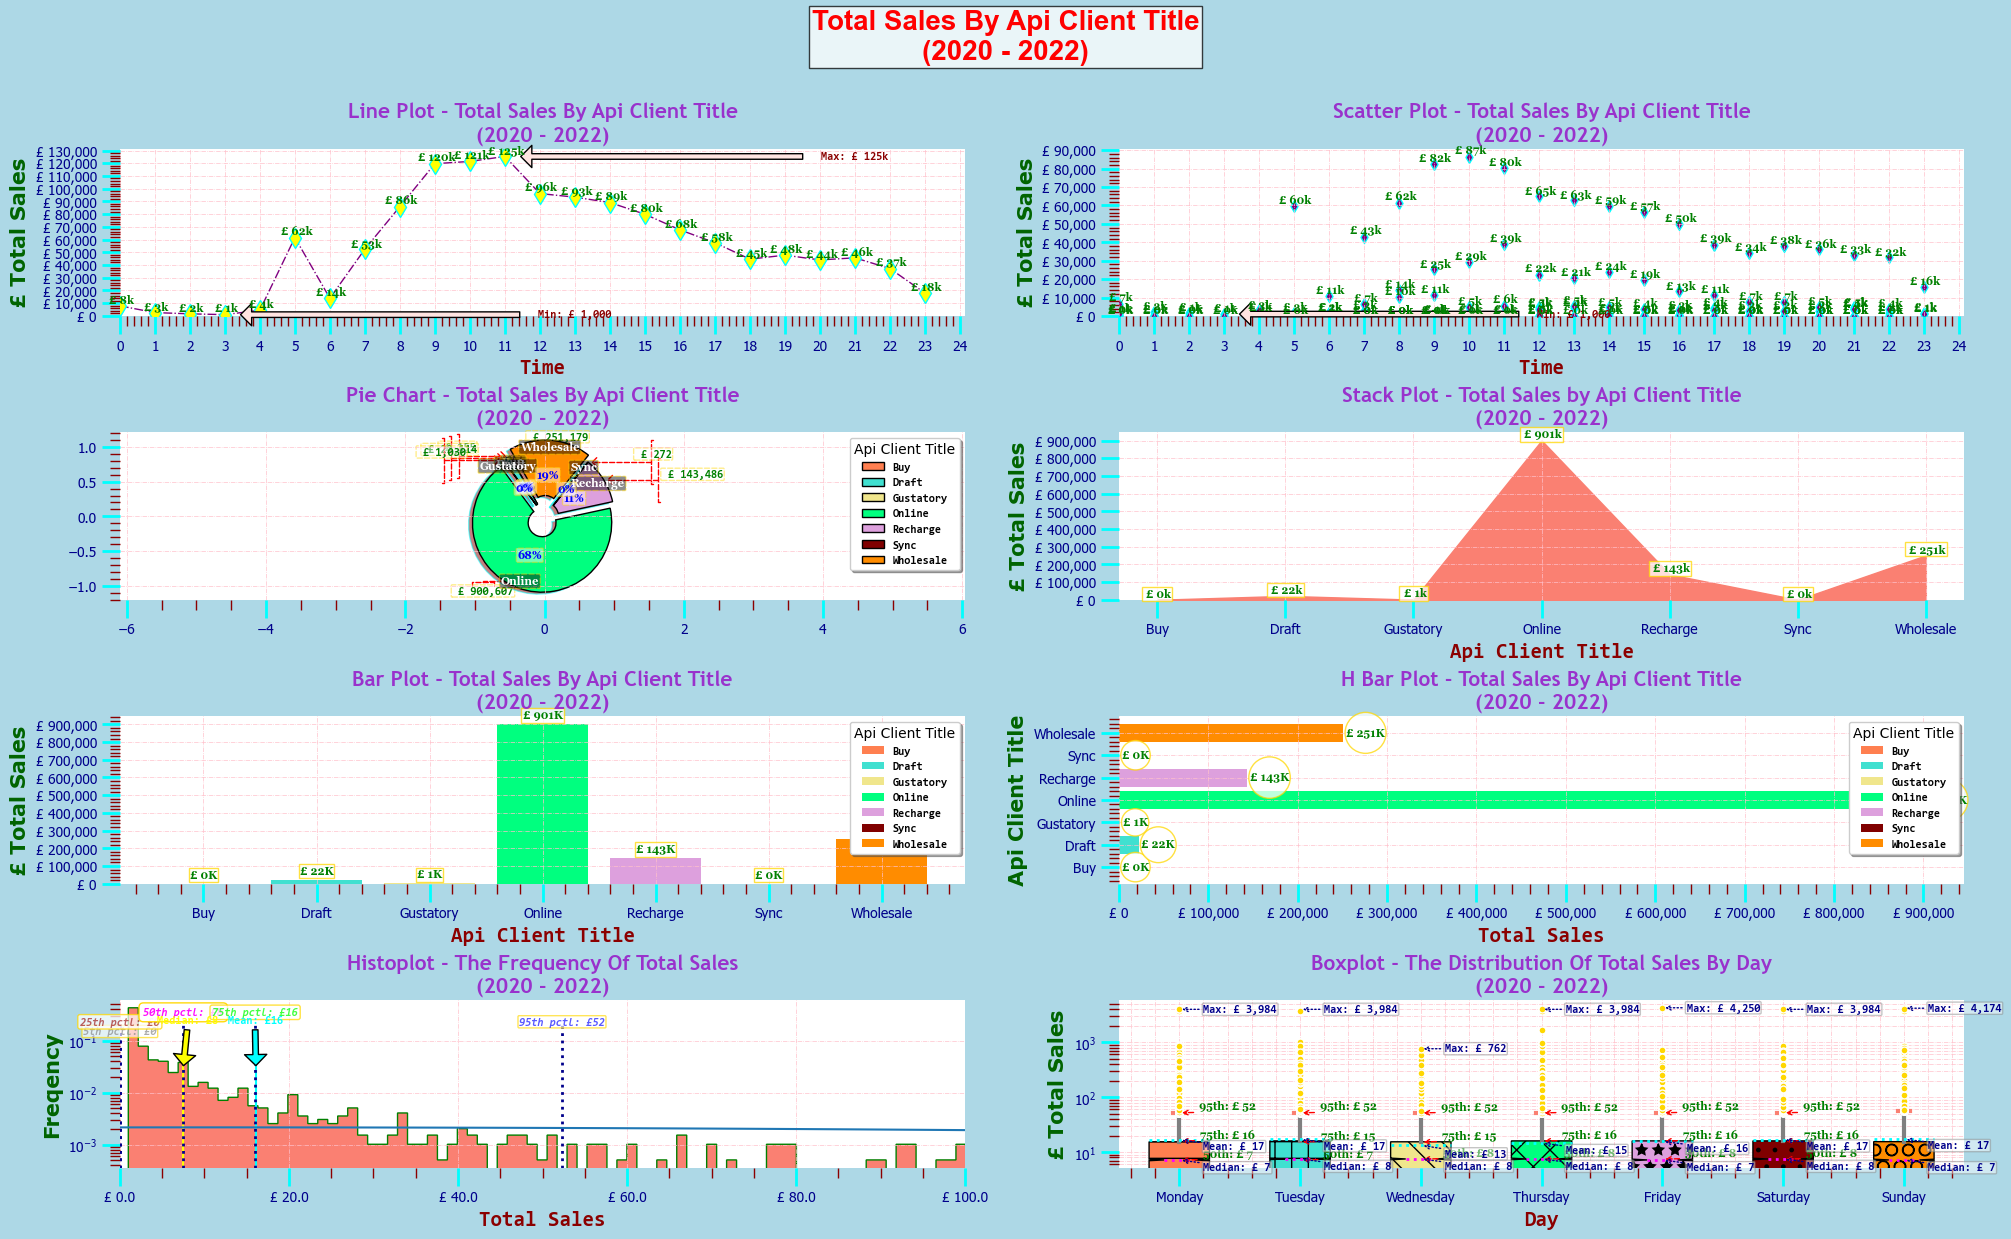

In [91]:
#ADD SUBPLOT#
line_yvalues = df16['total_sales']
line_xvalues = df16['time']
# Find index of minumum value
min_index=np.argmin(line_yvalues)
# Get the x and y values at the minimum index
min_x = line_xvalues[min_index]
min_y = line_yvalues[min_index]
# Find index of maximun value
max_index=np.argmax(line_yvalues)
# Get the x and y values at the maximum index
max_x = line_xvalues[max_index]
max_y = line_yvalues[max_index]

#==#
bar_yvalues = df17['total_sales']
#bar_xvalues = df17['api_client_title']
bar_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
pie_yvalues = df17['total_sales']
#pie_xvalues = df17['api_client_title']
pie_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
stack_yvalues = df17['total_sales']
#stack_xvalues = df17['api_client_title']
stack_xvalues = ['Buy','Draft','Gustatory','Online','Recharge','Sync','Wholesale']
#==#
scatter_yvalues=df18['total_sales']
scatter_xvalues=df18['time']
#==#

##

x_label_font = {'family':'consolas','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
subplot_title_font = {'family':'Arial','size':20,'style':'normal','weight':'bold'}
title_font = {'family':'trebuchet ms','color':'darkorchid','size':15,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

#==#

fig = plt.figure(figsize=(20,12),layout='constrained',facecolor='lightblue',dpi=100)

#==#

#LINE PLOT
ax1 = fig.add_subplot(421) #421,341

#SCATTERPLOT
ax2 = fig.add_subplot(422) #422,342

#PIE CHART
ax3 = fig.add_subplot(423) #423,343

#HISTOGRAM PLOT
ax4 = fig.add_subplot(424) #424,344

#BAR GRAPH
ax5 = fig.add_subplot(425) #425,325

#HORIZONTAL BAR GRAPH
ax6 = fig.add_subplot(426) #426,326

#STACKPLOT
ax7 = fig.add_subplot(427) #427,32#

#BOXPLOT
ax8 = fig.add_subplot(428) #428,32#

#==#

fig.suptitle('Total Sales By Api Client Title\n' + '(2020 - 2022)',ha='center',va='center',color='red',stretch=None,fontproperties=subplot_title_font,
bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='black'))

#==#

## LINE PLOT ###
ax1.plot(line_xvalues,line_yvalues,label=line_xvalues,marker='d',markersize=10,markeredgecolor='cyan',markerfacecolor='yellow',linestyle='dashdot',color='purple',linewidth=1)
ax1.set_xlabel('Time',loc='center',fontdict=x_label_font)
ax1.set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax1.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax1.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
ax1.set_yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000,130000])
ax1.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax1.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax1.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax1.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax1.minorticks_on()
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['bottom','left']].set_visible(False)
ax1.set_facecolor('white')
ax1.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax1.set_title('Line Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# Annotate the minimum value in the plot
ax1.annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot
ax1.annotate(f'Max: £ {max_y/1000:,.0f}k',xy=(max_x,max_y),xytext=(max_x+10,max_y),textcoords='data',ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in text format
for x, line_yvalues in zip(line_xvalues, line_yvalues):
     ax1.text(x,line_yvalues,f" £ {line_yvalues/1000:,.0f}k",fontdict=text_font)

#==#

## SCATTER PLOT ##
ax2.scatter(scatter_xvalues,scatter_yvalues,label=scatter_xvalues,marker='d',edgecolor='cyan',color='purple',linewidths=1)
ax2.set_xlabel('Time',loc='center',fontdict=x_label_font)
ax2.set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax2.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax2.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
ax2.set_yticks([0,10000,20000,30000,40000,50000,60000,70000,80000,90000,])
ax2.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax2.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax2.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax2.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax2.minorticks_on()
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['bottom','left']].set_visible(False)
ax2.set_facecolor('white')
ax2.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax2.set_title('Scatter Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)

# Annotate the minimum value in the plot
ax2.annotate(f'Min: £ {min_y:,.0f}',xy=(min_x,min_y),xytext=(min_x+10,min_y ),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate the maximum value in the plot
ax2.annotate(f'Max: £ {max_y/1000:,.0f}k',xy=(max_x,max_y),xytext=(max_x+10,max_y ),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='darkred',rotation=0,
arrowprops=dict(facecolor='mistyrose',headwidth=16,headlength=8,width=4,shrink=0.05))

# Annotate y-values in text format
for x, scatter_yvalues in zip(scatter_xvalues, scatter_yvalues ):
     ax2.text(x,scatter_yvalues ,f" £ {scatter_yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0)

#==#

## PIE CHART ##
pie_text = {'ha':'center','va':'center','family':'georgia','color':'darkblue','size':8,'style':'normal','weight':'bold'}
pie_shape = {"linewidth":1,'width':0.8,"edgecolor":"k"}
pie_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
pie_shadow = {'ox':-0.04,'edgecolor':'cyan','shade':0.9,'facecolor':'darkred'}
myexplode = (0,0,0,0.1,0,0,0.1)


wedges, texts, autotexts = ax3.pie(pie_yvalues,labels=pie_xvalues,autopct='%.0f%%',textprops=pie_text,wedgeprops=pie_shape,frame=True,center=(0,0),pctdistance=0.5,
labeldistance=0.90,colors=pie_colours,explode=myexplode,shadow=pie_shadow,startangle=120)

ax3.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax3.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax3.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax3.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax3.minorticks_on()
ax3.spines[['top','right']].set_visible(False)
ax3.spines[['bottom','left']].set_visible(False)
ax3.set_facecolor('white')
ax3.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax3.set_title('Pie Chart - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontweight='bold',fontdict=title_font)
ax3.legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
ax3.autoscale()
ax3.axis('equal')

#==#

# Annotate each wedge
for i, wedge in enumerate(wedges):
     # Only annotate if the value is greater than zero
     if pie_yvalues[i] > 0: 
          # Calculate the angle of the wedge's center
          angle = (wedge.theta2 + wedge.theta1) / 2
          #angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1 
          
          # Calculate the position to place the annotation
          x = np.cos(np.radians(angle))
          y = np.sin(np.radians(angle))
          
          ann_x = 2.5 * x # Adjust for desired annotation position - Outwards
          ann_y = 1.15 * y # Adjust for desired annotation position - Upwards
        
#==#

# Draw the arrow
     bbox_props = dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45) 
     kw = dict(arrowprops=dict(arrowstyle="]->",color='red',mutation_aspect=2,linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=1,
     connectionstyle='angle,angleA=-90,angleB=180,rad=0'),bbox=bbox_props,zorder=0,)
    
# Annotate y-values in arrow format
     ax3.annotate(f' £ {pie_yvalues[i]:,.0f}',xy=(x, y),xycoords='data',xytext=(ann_x, ann_y),textcoords='data',
     ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='green',rotation=0,**kw)

# Annotate each wedge with its category label in bbox square format
for i, text in enumerate(texts):
    text.set_bbox(dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45))
    text.set_backgroundcolor('black')
    text.set_color('white')
    
# Annotate each wedge with its x-value/percentage in bbox round format
for autotext in autotexts:
    autotext.set_bbox(dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=0.45))
    autotext.set_backgroundcolor('white')
    autotext.set_color('blue')

#==#

## STACK PLOT ##
ax4.stackplot(stack_xvalues,stack_yvalues,color='salmon',hatch=None,baseline='zero',data=None)
ax4.set_xlabel('Api Client Title',loc='center',fontdict=x_label_font)
ax4.set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax4.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax4.set_yticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,])
ax4.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax4.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax4.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax4.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax4.spines[['top','right']].set_visible(False)
ax4.spines[['bottom','left']].set_visible(False)
ax4.set_facecolor('white')
ax4.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
ax4.set_title('Stack Plot - Total Sales by Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax4.set_ylim(bottom=0)

#==#
    
# Annotate y-values in bbox square format
for x, stack_yvalues in zip(stack_xvalues, stack_yvalues):
     ax4.text(x,stack_yvalues,f" £ {stack_yvalues/1000:,.0f}k",ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
             bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
#==#

## BAR PLOT ##
bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

ax5.bar(bar_xvalues,bar_yvalues,label=bar_xvalues,color=bar_colours)
ax5.set_xlabel('Api Client Title',loc='center',fontdict=x_label_font)
ax5.set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax5.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax5.set_yticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,])
ax5.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax5.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax5.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax5.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax5.minorticks_on()
ax5.spines[['top','right']].set_visible(False)
ax5.spines[['bottom','left']].set_visible(False)
ax5.set_facecolor('white')
ax5.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax5.set_title('Bar Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax5.legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
ax5.set_ylim(bottom=0)

# Annotatr y-values in bbox square format
for c in ax5.containers:
    labels = [f'£ {(v.get_height() / 1000):,.0f}K' for v in c]
    ax5.bar_label(c,labels=labels,label_type='edge',padding=2,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="square",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
    
#==#

## H-BAR PLOT ##
bar_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']

ax6.barh(bar_xvalues,bar_yvalues,align='center',label=bar_xvalues,color=bar_colours)
ax6.set_xlabel('Total Sales',loc='center',fontdict=x_label_font)
ax6.set_ylabel('Api Client Title',loc='center',fontdict=y_label_font)
ax6.xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax6.set_xticks([0,100000,200000,300000,400000,500000,600000,700000,800000,900000,])
ax6.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax6.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax6.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax6.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax6.minorticks_on()
ax6.spines[['top','right']].set_visible(False)
ax6.spines[['bottom','left']].set_visible(False)
ax6.set_facecolor('white')
ax6.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax6.set_title('H Bar Plot - Total Sales By Api Client Title\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax6.legend(title='Api Client Title',loc='upper right',prop={'family':'consolas','style':'normal','weight':'bold','size':8},shadow=True,fancybox=True)
ax6.set_xlim(left=0)

# Annotate values in bbox circle format
for c in ax6.containers:
    labels = [f'£ {(v.get_width() / 1000):,.0f}K' for v in c]
    ax6.bar_label(c, labels=labels, label_type='edge',padding=2,family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
                   bbox=dict(boxstyle="circle",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'))
    
#==#

## HISTOGRAM ##
histogram = df['total_sales'].value_counts()

# Calculate the min, max, median, mean, mode & range
min_total_sales = df['total_sales'].min()
max_total_sales = df['total_sales'].max()
median_total_sales = df['total_sales'].median()
mean_total_sales = df['total_sales'].mean() 
mode_total_sales = df['total_sales'].mode()
range_total_sales = (max_total_sales)-(min_total_sales)

# Assign bins
bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170]

ax7.hist(x=histogram,bins='auto',density=True,histtype='stepfilled',align='mid',orientation='vertical',rwidth=0.95,log=True,color='salmon',label=None,stacked=False,data=None,
edgecolor='green')
ax7.set_xlabel('Total Sales',loc='center',fontdict=x_label_font)
ax7.set_ylabel('Freqency',loc='center',fontdict=y_label_font)
ax7.xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax7.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax7.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax7.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax7.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax7.minorticks_on()
ax7.spines[['top','right']].set_visible(False)
ax7.spines[['bottom','left']].set_visible(False)
ax7.set_facecolor('white')
ax7.grid(which='major',linestyle='dashdot',color='pink',linewidth=0.5)
ax7.set_title('Histoplot - The Frequency Of Total Sales\n' + '(2020 - 2022)',loc='center',fontweight='bold',fontdict=title_font)
ax7.set_xlim(0,100)

# Assign new variable names to min, max, median, mean, mode & range
min = min_total_sales
max = max_total_sales
median = median_total_sales
mean = mean_total_sales
mode = mode_total_sales
range= range_total_sales

# Create vertical lines for min, max, median, mean & range
ax7.vlines([min],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='red')
ax7.vlines([max],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='lime')
ax7.vlines([median],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='yellow')
ax7.vlines([mean],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='cyan')
ax7.vlines([range],ymin=0,ymax=0.1,ls='solid',lw=1.5,color='grey')

# Add KDE on to a histogram
kde = stats.gaussian_kde(histogram)
xx = np.linspace(0, 100)
ax7.plot(xx, kde(xx))

# Calculate percentiles
quant_5, quant_25, quant_50, quant_75, quant_95 = \
df['total_sales'].quantile(0.05),df['total_sales'].quantile(0.25), df['total_sales'].quantile(0.5),df['total_sales'].quantile(0.75),df['total_sales'].quantile(0.95)
# [quantile, opacity/transparency, length]
quants = [[quant_5, 1, 0.85], [quant_25, 1, 0.85], [quant_50, 1, 0.85],  [quant_75, 1, 0.85], [quant_95, 1, 0.85]]

# Plot the lines with a loop
for i in quants:
    ax7.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = "dotted", linewidth=2, color = 'darkblue')

# Create Percentile font dictionary
pctl_5_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='grey',rotation=0,alpha=0.65)
pctl_25_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='brown',rotation=0,alpha=0.75)
pctl_50_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='magenta',rotation=0,alpha=0.95)
pctl_75_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='lime',rotation=0,alpha=0.75)
pctl_95_fontdict = dict(ha='center',va='center',family='consolas',fontstyle='italic',fontsize=8,fontweight='semibold',color='blue',rotation=0,alpha=0.65)

# Annotations percentiles & values to axes in bbbox round format - (Axes.text(x, y, s('text'), fontdict=None, **kwargs))
ax7.text(quant_5,0.15,f'5th pctl: £{pctl_5:,.0f}',fontdict=pctl_5_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))
ax7.text(quant_25,0.23,f'25th pctl: £{pctl_25:,.0f}',fontdict=pctl_25_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
ax7.text(quant_50,0.35,f'50th pctl: £{pctl_50:,.0f}',fontdict=pctl_50_fontdict,bbox=dict(boxstyle="round",pad=0.4,facecolor='white',edgecolor='gold',alpha=0.95,))
ax7.text(quant_75,0.35,f'75th pctl: £{pctl_75:,.0f}',fontdict=pctl_75_fontdict,bbox=dict(boxstyle="round",pad=0.2,facecolor='white',edgecolor='gold',alpha=0.75,))
ax7.text(quant_95,0.23,f'95th pctl: £{pctl_95:,.0f}',fontdict=pctl_95_fontdict,bbox=dict(boxstyle="round",pad=0.1,facecolor='white',edgecolor='gold',alpha=0.65,))

# Annotate Median & Mean to axes in arrow format
ax7.annotate(f'Median: £{median:,.0f}',xy=(median,0.03),xytext=(8,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='yellow',rotation=0,
arrowprops=dict(facecolor='yellow',headwidth=16,headlength=8,width=4,shrink=0.05))

ax7.annotate(f'Mean: £{mean:,.0f}',xy=(mean,0.03),xytext=(16,0.25),ha='center',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',color='cyan',rotation=0,
arrowprops=dict(facecolor='cyan',headwidth=16,headlength=8,width=4,shrink=0.05))

#==##

## BOXPLOT ##
matplot_boxplot = df.copy()
matplot_boxplot
matplot_boxplot['index'] = matplot_boxplot.index

#==#

# Pivot the DataFrame
data_day = matplot_boxplot.pivot(index='index', columns='day', values='total_sales')

# Inspect the columns of the pivoted DataFrame
#print(data_day.columns)

# Accessing the MultiIndex columns correctly
days = ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
# Filter only the days present in the DataFrame
days_present = [day for day in days if day in data_day.columns]

# Collecting data for each day
l = [data_day[day].dropna() for day in days_present]
l

#==#

labels = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
boxplot_colours = ['coral','turquoise','khaki','springgreen','plum','maroon','darkorange']
boxplot_hatchs = ['-', '+', '\\','x','*','.','O']

#==#

gold_flier = dict(marker='o',markerfacecolor='gold',markeredgecolor='white',markersize=5)
salmon_cap = dict(color='salmon',linewidth=3,linestyle='solid')
grey_whisker = dict(color='grey',linewidth=3,linestyle='solid')
cyan_mean = dict(color='cyan',linewidth=2,linestyle='dotted')
magenta_median = dict(color='magenta',linewidth=2,linestyle='dotted')
black_box = dict(edgecolor='black',linewidth=1,linestyle='solid')

boxplot_style = dict(flierprops=gold_flier,capprops=salmon_cap,whiskerprops=grey_whisker,meanprops=cyan_mean,medianprops=magenta_median,boxprops=black_box)

#==#

boxplot = ax8.boxplot(l,notch=True,sym=None,vert=True,whis=[0,95],positions=None,widths=None,patch_artist=True,bootstrap=None,**boxplot_style,
usermedians=None,conf_intervals=None,meanline=True,showmeans=True,manage_ticks=True,autorange=False,zorder=None,capwidths=0.1,labels=labels,data=l)
ax8.set_xlabel('Day',loc='center',fontdict=x_label_font)
ax8.set_ylabel('£ Total Sales',loc='center',fontdict=y_label_font)
ax8.yaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
ax8.tick_params(axis='x',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax8.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize='medium',labelcolor='darkblue',labelfontfamily='tahoma',labelrotation=None,grid_linewidth=0.5)
ax8.tick_params(axis='x',which='minor',bottom=True,length=7,width=1,color='darkred')
ax8.tick_params(axis='y',which='minor',bottom=True,length=7,width=1,color='darkred')
ax8.minorticks_on()
ax8.spines[['top','right']].set_visible(False)
ax8.spines[['bottom','left']].set_visible(False)
ax8.set_facecolor('white')
ax8.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)
ax8.set_title('Boxplot - The Distribution Of Total Sales By Day\n' + '(2020 - 2022)',loc='center',fontdict=title_font)
ax8.set_yscale('log')

#==#

# Annotate the catplot/boxplot with percentiles in arrows format
percentiles = [5, 25, 50, 75, 95]
for i, category in enumerate(matplot_boxplot['day'].unique()):
    subset = matplot_boxplot[matplot_boxplot['day'] == category]['total_sales']
    for percentile in percentiles:
        value = np.percentile(subset, percentile)
        # Annotate the percentiles on the plot
        ax8.annotate(f'{percentile}th: £ {value:,.0f}',xy=(i,value),xytext=(i+0.40,value),
        ha='center',va='bottom',family='georgia',color='green',size=8,style='normal',weight='bold',rotation=0,
        #bbox=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.75,edgecolor='gold'),
        arrowprops=dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dashed',capstyle='round',joinstyle='round',alpha=1,
        connectionstyle='angle3,angleA=90,angleB=0')) # "]->" - 'angle,angleA=-90,angleB=180,rad=0', "->" - 'angle3,angleA=90,angleB=0'

#==#

# Assign colors to each box in the boxplot
for box, color, hatch in zip(boxplot['boxes'],boxplot_colours,boxplot_hatchs):
    box.set_facecolor(color)
    box.set(hatch=hatch)

#==#

# Annotating the boxplot with min, max, median, and mean values
for i, data in enumerate(l):
    mean_val = np.mean(data)
    median_val = np.median(data)
    min_val = np.min(data)
    max_val = np.max(data)

#==#

    arrow = dict(arrowstyle="->",color='darkblue',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
    box=dict(boxstyle="round",pad=0.1,facecolor='white',alpha=0.45,edgecolor='grey')

#==#

# Plot arrows
    ax8.annotate(f'Min: £ {min_val:,.0f}',xy=(i+1,min_val),xytext=(i+1+0.2,min_val-1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax8.annotate(f'Max: £ {max_val:,.0f}',xy=(i+1,max_val),xytext=(i+1+0.2,max_val+1),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax8.annotate(f'Median: £ {median_val:,.0f}',xy=(i+1,median_val),xytext=(i+1+0.2,median_val-2),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0,arrowprops=arrow,bbox=box)
    ax8.annotate(f'Mean: £ {mean_val:,.0f}', xy=(i+1,mean_val), xytext=(i+1+0.2, mean_val-4),ha='left',va='center',family='consolas',fontstyle='normal',fontsize=8,fontweight='bold',
    color='darkblue',rotation=0, arrowprops=arrow,bbox=box)

#==#

plt.show(close=None,block=None)